# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import seaborn as sns

In [3]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [38]:
import os
import shutil
import pickle

import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path

from scipy.optimize import linear_sum_assignment

import drvi
from drvi.utils.metrics import DiscreteDisentanglementBenchmark
from drvi_notebooks.utils.data import data_registry, get_data_info
from drvi_notebooks.utils.run_info import get_run_info_for_dataset
from drvi_notebooks.utils.method_info import pretify_method_name, methods_general_order
from drvi_notebooks.utils.misc import get_runs_by_model_tags
from sklearn.metrics import mutual_info_score

import wandb

In [5]:
sc.set_figure_params(vector_friendly=True, dpi_save=300, figsize=(6,6))

# Config

In [6]:
cwd = os.getcwd()

In [7]:
logs_dir = Path(os.path.expanduser('~/workspace/train_logs'))
logs_dir

PosixPath('/home/icb/amirali.moinfar/workspace/train_logs')

In [8]:
proj_dir = Path(cwd).parent.parent
proj_dir

PosixPath('/lustre/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public')

In [9]:
output_dir = proj_dir / 'plots' / 'immune_baseline_failures'
output_dir.mkdir(parents=True, exist_ok=True)
output_dir

PosixPath('/lustre/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public/plots/immune_baseline_failures')

In [10]:
run_name = 'immune_hvg'
run_version = '4.3'
run_path = os.path.expanduser('~/workspace/train_logs/models')

data_info = get_data_info(run_name, run_version)
wandb_address = data_info['wandb_address']
col_mapping = data_info['col_mapping']
plot_columns = data_info['plot_columns']
pp_function = data_info['pp_function']
data_path = data_info['data_path']
cell_type_key = data_info['cell_type_key']
control_treatment_key = data_info['control_treatment_key']
condition_key = data_info['condition_key']
split_key = data_info['split_key']

In [11]:
import mplscience
mplscience.available_styles()
mplscience.set_style()

['default', 'despine']


In [12]:
cat_10_pallete = sc.plotting.palettes.vega_10_scanpy
cat_10_pallete_without_grey = [c for c in cat_10_pallete if c != '#7f7f7f']
cat_20_pallete = sc.plotting.palettes.vega_20_scanpy
wong_pallete = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000",
]
cat_100_pallete = sc.plotting.palettes.godsnot_102

## Utils

In [13]:
def trim_umap(embed, old_key='X_umap', new_key='X_umap', threshold=1e-5):
    x_min, x_max = np.quantile(embed.obsm[old_key][:, 0], (threshold, 1-threshold))
    x_min, x_max = float(x_min), float(x_max)
    y_min, y_max = np.quantile(embed.obsm[old_key][:, 1], (threshold, 1-threshold))
    y_min, y_max = float(y_min), float(y_max)
    embed.obsm[new_key] = np.vstack([embed.obsm[old_key][:, 0].clip(x_min, x_max), embed.obsm[old_key][:, 1].clip(y_min, y_max)]).T

# Runs to load

In [14]:
api = wandb.Api()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/icb/amirali.moinfar/.netrc.


In [15]:
api.flush()
RUNS_TO_LOAD = get_runs_by_model_tags(
    api, 
    ["DRVI_runs_adata_hvg_drvi_4.3", "DRVI_runs__DRVI_5.0", "DRVI_runs__DRVI_baselines_2.0"],
    {
        'DRVI': 'Immune_comparison_analysis_32__DRVI',
        'PCA': 'Immune_comparison_analysis_32__PCA',
        'ICA': 'Immune_comparison_analysis_32__ICA',
        'LIGER': 'Immune_comparison_analysis_32__LIGER',
        'MOFA': 'Immune_comparison_analysis_32__MOFA',
        'scETM': 'Immune_comparison_analysis_32__scETM',
    },
)


RUNS_TO_LOAD

{'DRVI': [<Run moinfar_proj/DRVI_runs_adata_hvg_drvi_4.3/gwg9u9sv (finished)>],
 'PCA': [<Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/br7ewmkp (finished)>],
 'ICA': [<Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/7113idbn (finished)>],
 'LIGER': [<Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/7yhkfcrf (finished)>],
 'MOFA': [<Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/l79tb84t (finished)>],
 'scETM': [<Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/vtfh16s3 (finished)>]}

In [16]:
RUNS_TO_LOAD = {k:v[0] for k,v in RUNS_TO_LOAD.items() if len(v) > 0}
RUNS_TO_LOAD

{'DRVI': <Run moinfar_proj/DRVI_runs_adata_hvg_drvi_4.3/gwg9u9sv (finished)>,
 'PCA': <Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/br7ewmkp (finished)>,
 'ICA': <Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/7113idbn (finished)>,
 'LIGER': <Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/7yhkfcrf (finished)>,
 'MOFA': <Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/l79tb84t (finished)>,
 'scETM': <Run moinfar_proj/DRVI_runs__DRVI_baselines_2.0/vtfh16s3 (finished)>}

In [17]:
embeds = {}
run_paths = {}
random_order = None
for method_name, run in RUNS_TO_LOAD.items():
    run_path = Path(run.config.get('output_dir', Path(f'~/workspace/train_logs/models/{run.name}').expanduser()))
    run_paths[method_name] = run_path
    print(method_name)
    embed = sc.read(run_path / 'latent.h5ad')
    trim_umap(embed, threshold=1e-3)
    if random_order is None:
        random_order = embed.obs.sample(frac=1.).index
    embed = embed[random_order].copy()
    embeds[method_name] = embed

DRVI
PCA
ICA
LIGER
MOFA
scETM


In [18]:
adata = sc.read(data_path)
adata

AnnData object with n_obs × n_vars = 32484 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    var: 'gene_de_sig', 'mean', 'std'
    uns: 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [19]:
plot_obs = np.random.permutation(adata.obs.index)[:10000]

In [20]:
embed_drvi = embeds['DRVI']
model_drvi = drvi.model.DRVI.load(run_paths['DRVI'] / 'model.pt', adata, prefix='v_0_1_0_')


embed_new_filename = run_paths['DRVI'] / 'latent_v2_5.h5ad'

if not embed_new_filename.exists():
    # embed_drvi.var['title_prev'] = embed_drvi.var['title']
    model_drvi.set_latent_dimension_stats(embed_drvi, vanished_threshold=0.5)
    
    # print(np.all(embed_drvi.var['title'] == embed_drvi.var['title_prev']))  # Good. no change of DR orders
    
    model_drvi.calculate_interpretability_scores(embed_drvi, "OOD")
    model_drvi.calculate_interpretability_scores(embed_drvi, "IND")
    
    embed_drvi.write_h5ad(embed_new_filename)
else:
    embeds['DRVI'] = embed_drvi = sc.read_h5ad(embed_new_filename)
embed_drvi

INFO     File                                                                                                      
         /home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-115959-272081/model.pt/v_0_1_0_model.p
         t already downloaded                                                                                      
INFO     DRVI: The model is trained with DRVI version 0.1.0.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Modifying data args from 0.1.10 to 0.1.11 (no user action required)                                 
INFO     DRVI: Adding empty batch key ...                                                                          
INFO     DRVI: Done updating data source registry from 0.1.10 to 0.1.11.                                           
INFO     DRVI: Done updating data source registry. Loading in DRVI versi

AnnData object with n_obs × n_vars = 32484 × 32
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'log_lib', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'qz_mean'
    varm: 'IND_exp_weighted_mean_negative', 'IND_exp_weighted_mean_positive', 'IND_linear_weighted_mean_negative', 'IND_linear_weighted_mean_positive', 'IND_max_negative', 'IND_max_positive', 'OOD_combined_negative', 'OOD_combined_positive', 'OOD_max_possible_negative', 'OOD_max_possible_positive', 'OOD_min_possible_negative', 'OOD_min_possible_positive', 'PCs'
    obsp: 'connectivities', 'distances'

# Heatmaps

In [21]:
unique_plot_cts = list(sorted(embed_drvi.obs['final_annotation'].unique()))

In [22]:
embed = embeds['DRVI'].copy()  # or any other emb. no matter
embed_subset = drvi.utils.pl.make_balanced_subsample(embed, cell_type_key, min_count=20)
embed_subset.obs[cell_type_key] = pd.Categorical(embed_subset.obs[cell_type_key], unique_plot_cts)
embed_subset = embed_subset[embed_subset.obs.sort_values(cell_type_key).index].copy()

In [30]:
version = DiscreteDisentanglementBenchmark.version

for method_name, embed in embeds.items():
    print(method_name)
    bench_filename = run_paths[method_name] / f'disentanglement_metrics_{version}.pkl'
    if not bench_filename.exists():
        bench = DiscreteDisentanglementBenchmark(embed.X, discrete_target=embed.obs[cell_type_key])
        bench.evaluate()
        print(bench.get_results())
        bench.save(bench_filename)

DRVI
{'LMS-SMI': np.float64(0.6806034193707637), 'LMS-SPN': np.float64(0.6570060451083022), 'MSAS-SMI': np.float64(0.6950153725006812), 'MSAS-SPN': np.float64(0.6871395490566873), 'MSGS-SMI': np.float64(0.2845191170872209), 'MSGS-SPN': np.float64(0.33357970169781714)}
DRVI2
PCA
ICA
LIGER
MOFA
scETM


DRVI


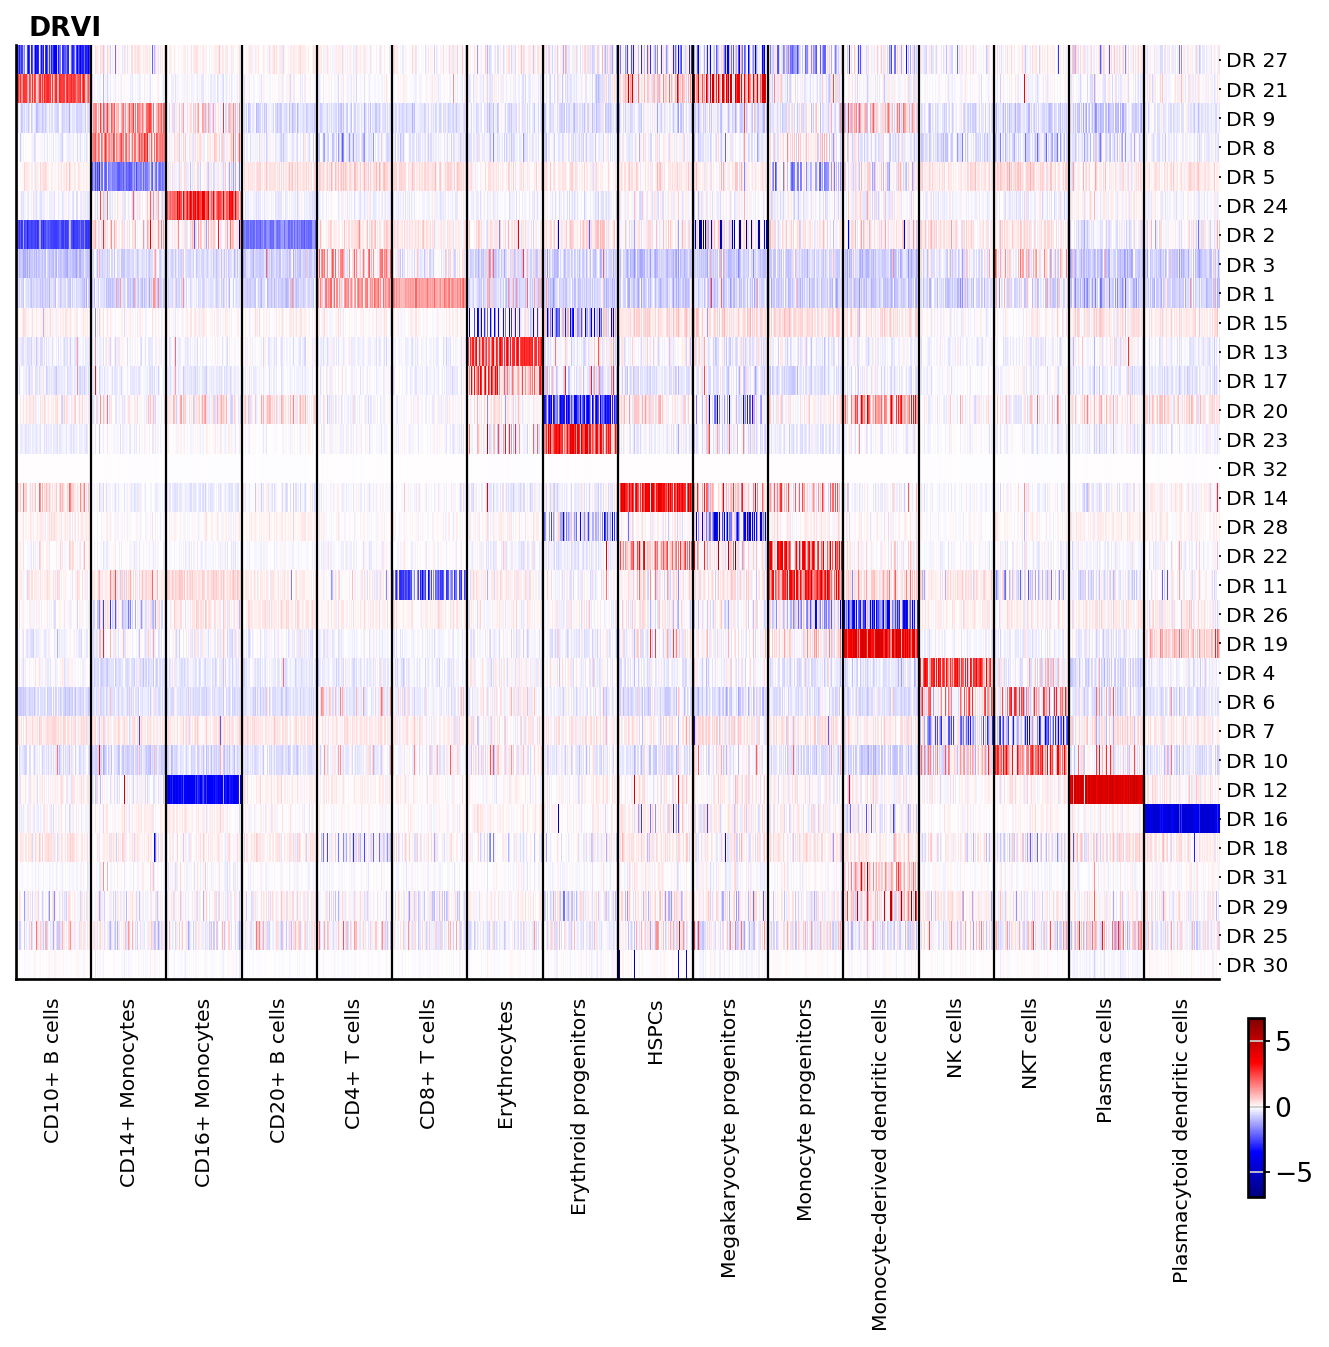

DRVI2


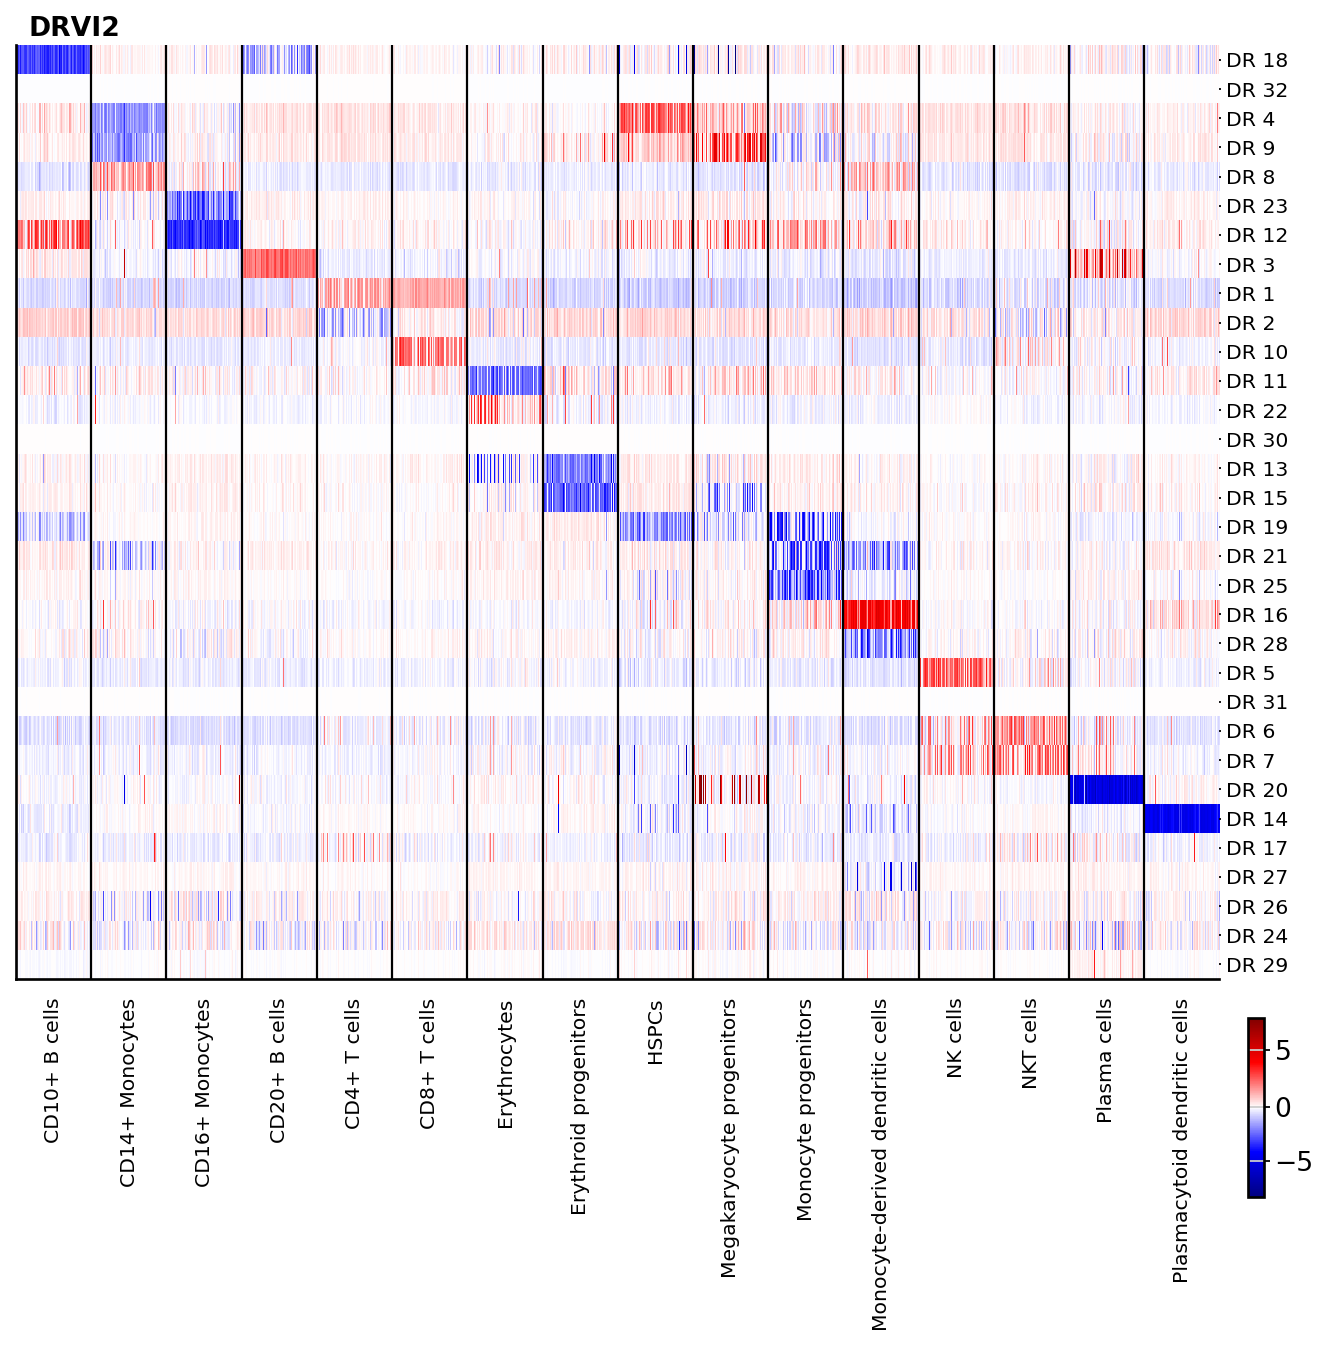

PCA


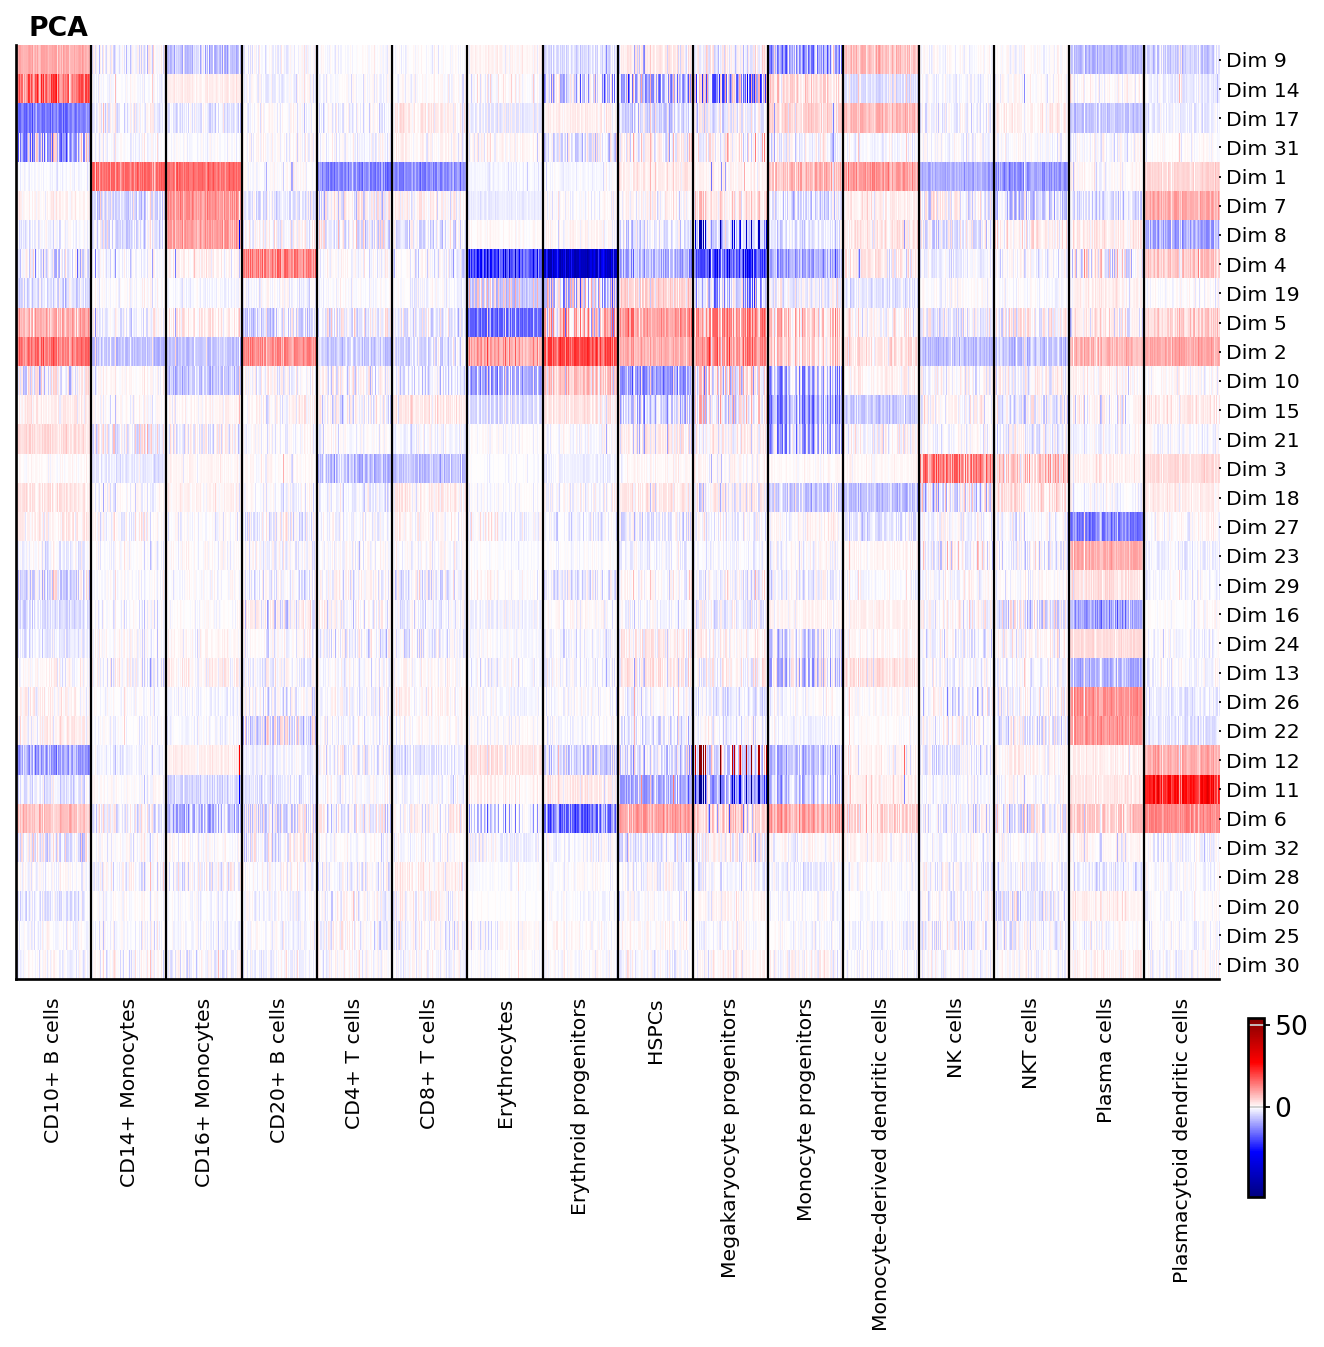

ICA


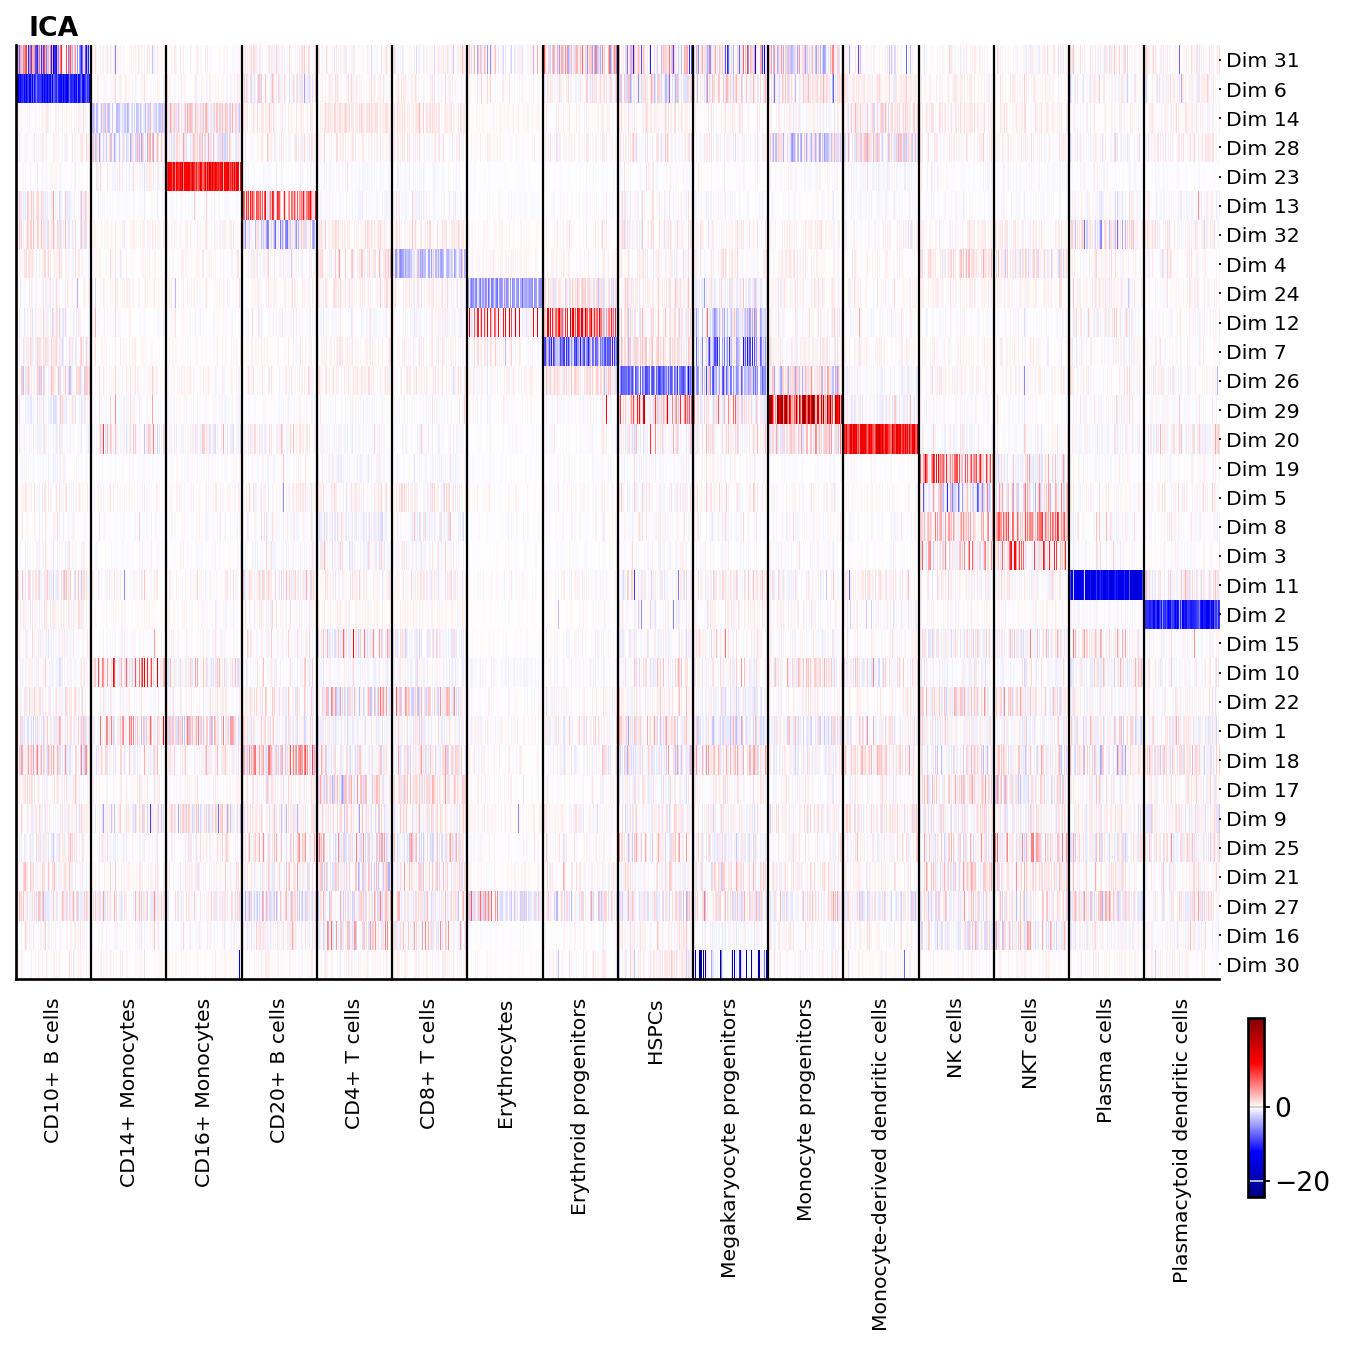

LIGER


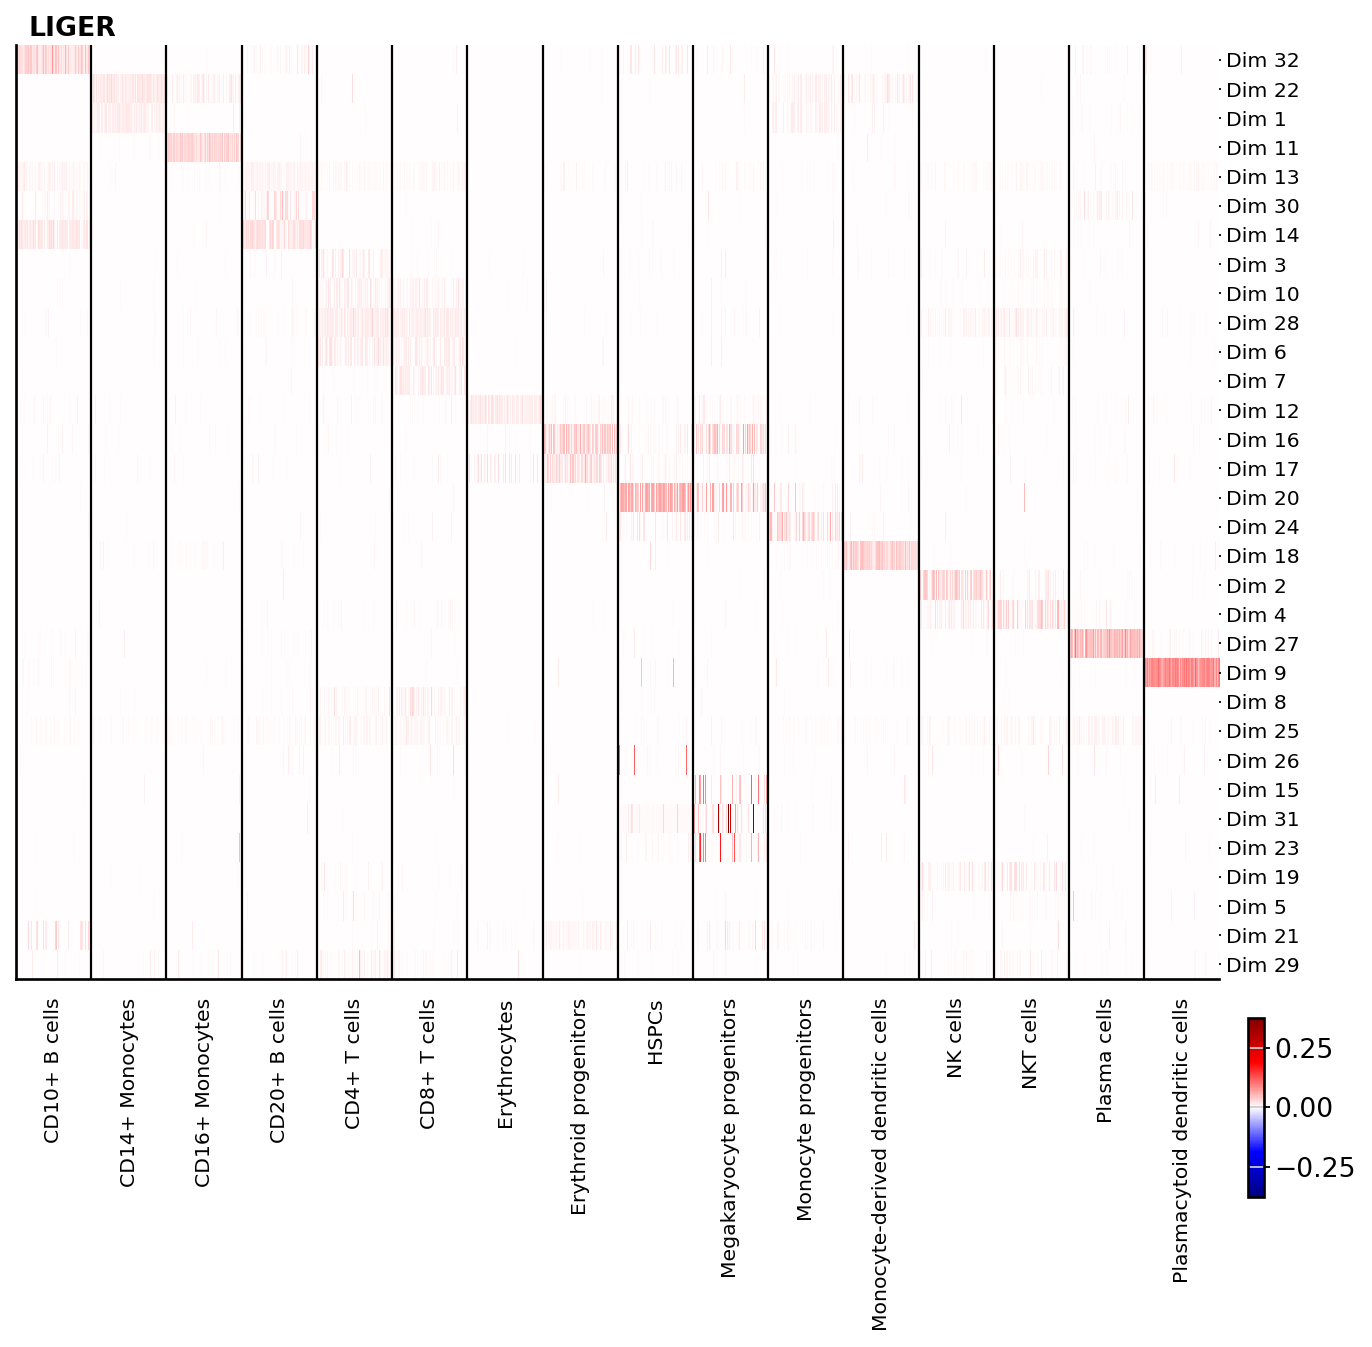

MOFA


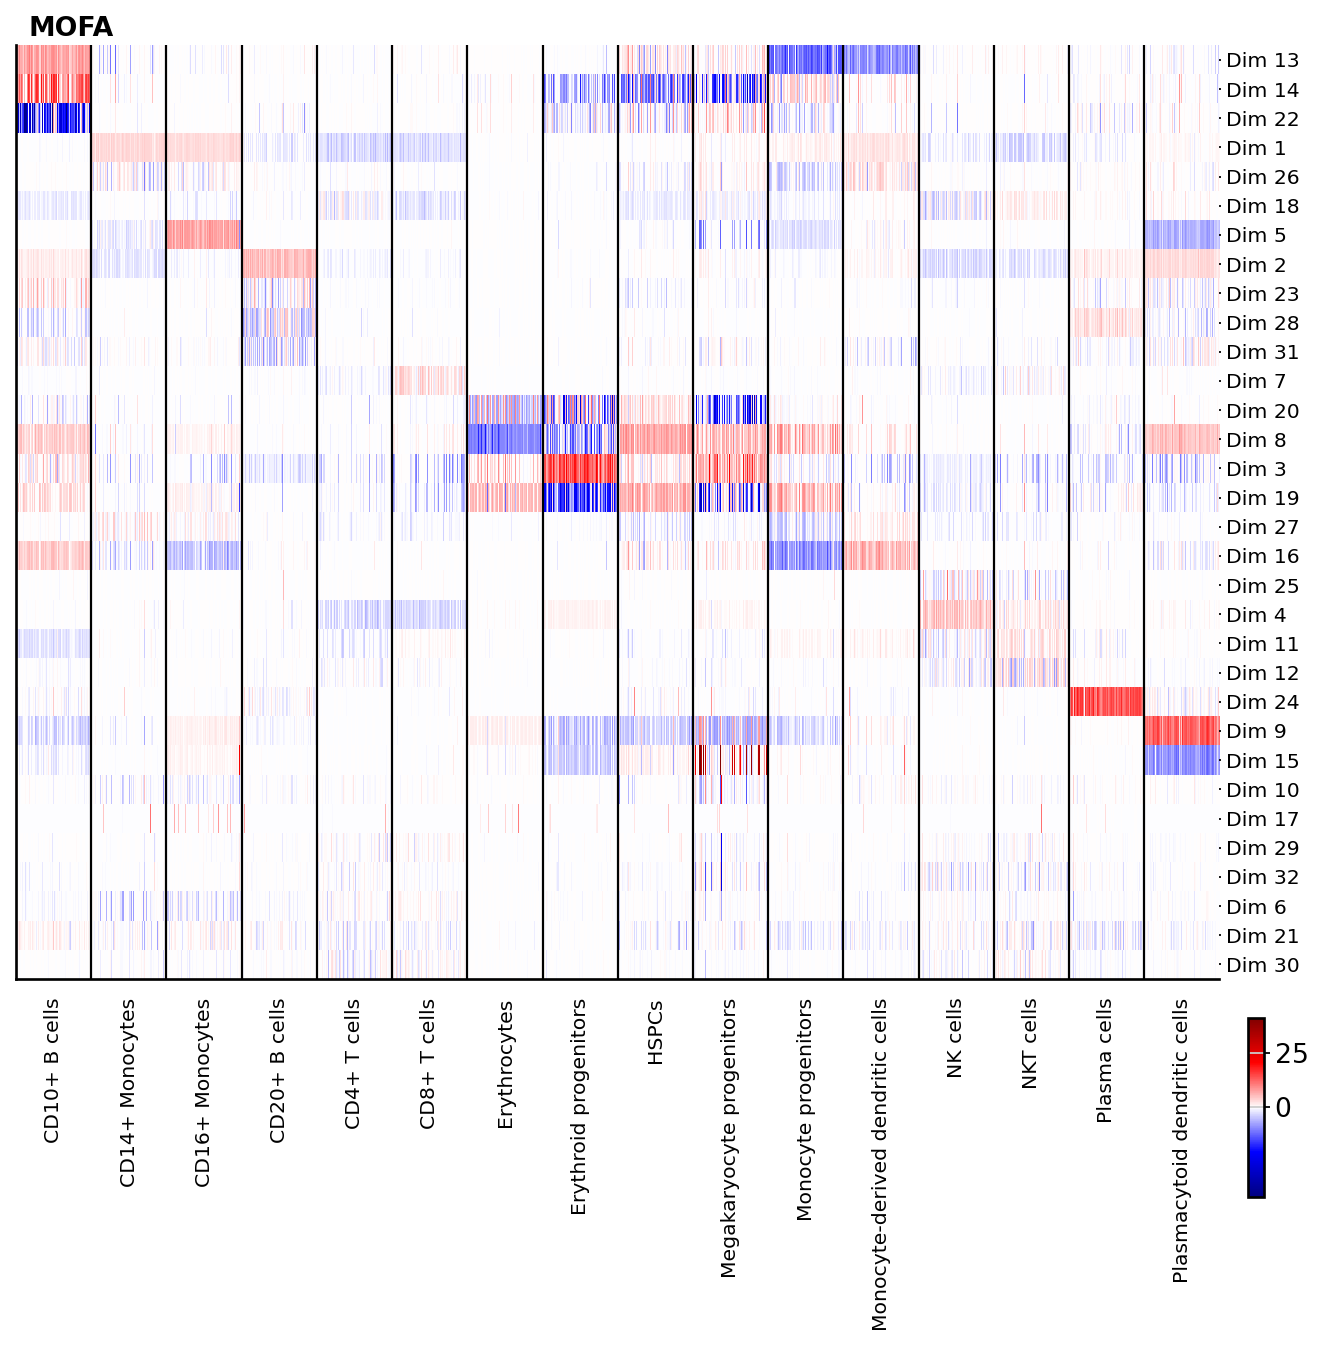

scETM


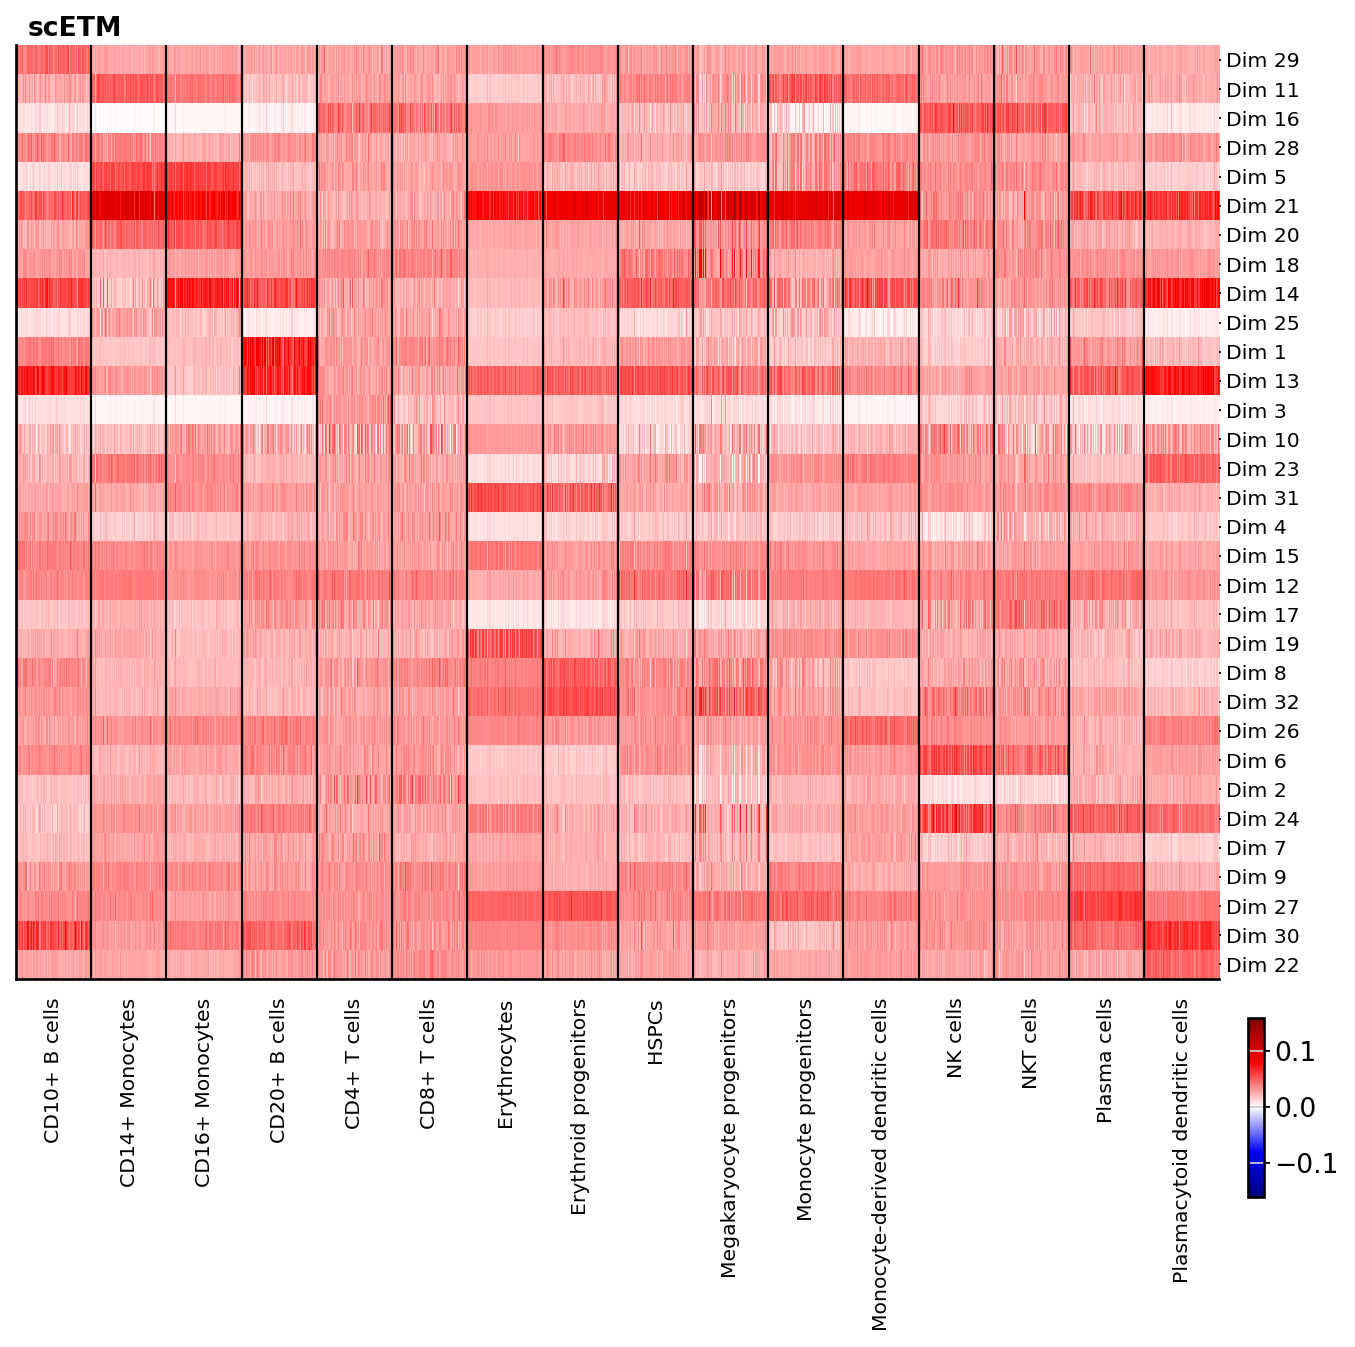

In [31]:
version = DiscreteDisentanglementBenchmark.version
    
for method_name, embed in embeds.items():
    print(method_name)

    bench_filename = run_paths[method_name] / f'disentanglement_metrics_{version}.pkl'
    bench = DiscreteDisentanglementBenchmark.load(bench_filename, embed.X, discrete_target=embed.obs[cell_type_key], one_hot_target=None)
    sim_matrix = bench.get_results_details()['SMI'][unique_plot_cts].copy()
    
    k = cell_type_key
    unique_values = list(sorted(list(embed.obs[k].astype(str).unique())))
    palette = dict(zip(unique_values, cat_100_pallete))
    method_embed_subset = embed[embed_subset.obs.index].copy()
    method_embed_subset.obs[cell_type_key] = pd.Categorical(method_embed_subset.obs[cell_type_key], unique_plot_cts)
    method_embed_subset = method_embed_subset[np.argsort(method_embed_subset.obs[cell_type_key].cat.codes)]
    method_embed_subset.uns[k + "_colors"] = 'black'
    vars = method_embed_subset.var
    vars['van'] = ~ (np.abs(method_embed_subset.X).max(axis=0, keepdims=True) > np.abs(method_embed_subset.X).max() / 5).flatten()
    vars['van'] = np.logical_and(vars['van'], (sim_matrix.max(axis=1) < 0.1).values)
    sim_matrix = (sim_matrix + 0.1) * (~(vars['van'].values[:, np.newaxis]))
    vars['plot_order'] = np.hstack([sim_matrix, sim_matrix * 0.01 + 0.3]).argmax(axis=1).tolist()
    if 'title' not in vars.columns:
        vars['title'] = np.char.add('Dim ', (1 + np.arange(method_embed_subset.n_vars)).astype(str))
        vars['order'] = np.arange(method_embed_subset.n_vars)
    vars['not_interesting'] = np.logical_or(vars['van'], vars['plot_order']==sim_matrix.shape[1])
    vars = pd.concat([vars.query('~not_interesting').sort_values('plot_order'), vars.query('not_interesting').sort_values('order')])
    # method_embed_subset.X = (method_embed_subset.X / method_embed_subset.X.max(axis=0, keepdims=True))
    fig = sc.pl.heatmap(
        method_embed_subset,
        vars['title'],
        k,
        gene_symbols = 'title',
        layer=None,
        # var_group_positions=[(0,30), (31, 51), (52, 63)],
        # var_group_labels=['Cell-type indicator', 'Biological Process', 'Vanished'],
        # var_group_rotation=0,
        figsize=(10, 8),
        show_gene_labels=True,
        dendrogram=False,
        vcenter=0,
        cmap=drvi.utils.pl.cmap.saturated_red_blue_cmap, show=False,
        swap_axes=True,
    )
    # fig['groupby_ax'].set_xlabel('Finest level annotation')
    fig['groupby_ax'].set_xlabel('')
    fig['groupby_ax'].get_images()[0].remove()
    pos = fig['groupby_ax'].get_position()
    pos.y0 += 0.015
    fig['groupby_ax'].set_position(pos)
    fig['heatmap_ax'].yaxis.tick_right()
    cbar = fig['heatmap_ax'].figure.get_axes()[-1]
    pos = cbar.get_position()
    # cbar.set_position([1., 0.77, 0.01, 0.13])
    cbar.set_position([.95, 0.001, 0.01, 0.14])

    ax = fig['heatmap_ax']
    ax.set_ylabel('')
    ax.text(0.01, 1.01, pretify_method_name(method_name), size=12, ha='left', weight='bold', color='black', rotation=0, transform=ax.transAxes)

    plt.savefig(output_dir / f"ct_vs_dim_heatmap_rotated_{method_name}.pdf", bbox_inches='tight')
    plt.show()

# Interpretability comparison

In [30]:
def plot_interpretability_scores(interpertability_df, n_top_genes=10, score_threshold=0., dim_subset=None, ncols=4, show=True):
    plot_info = [
        (k, v)
        for k, v in interpertability_df.to_dict(orient="series").items()
        if (v.max() >= score_threshold) and (dim_subset is None or k in dim_subset)
    ]
    
    n_row = int(np.ceil(len(plot_info) / ncols))
    fig, axes = plt.subplots(n_row, ncols, figsize=(3 * ncols, int(1 + 0.2 * n_top_genes) * n_row))
    
    for ax, info in zip(axes.flatten(), plot_info, strict=False):
        top_indices = info[1].sort_values(ascending=False)[:n_top_genes]
        if len(top_indices) > 0:
            ax.barh(top_indices.index, top_indices.values, color="skyblue")
            ax.set_xlabel("Gene Score")
            ax.set_title(info[0])
            ax.invert_yaxis()
        ax.grid(False)
    
    for ax in axes.flatten()[len(plot_info) :]:
        fig.delaxes(ax)
    
    plt.tight_layout()
    if show:
        plt.show()
    else:
        return fig

In [23]:
int_dfs = {}
for method_name, embed in embeds.items():
    if method_name == 'DRVI':
        int_df = model_drvi.get_interpretability_scores(embed, adata)
        int_df = int_df.loc[:, (int_df.max(axis=0)>0.1).to_list()]
        int_dfs[method_name] = int_df
    elif method_name == 'DRVI2':
        model_drvi2 = drvi.model.DRVI.load(run_paths['DRVI2'] / 'model.pt', adata)
        int_df = model_drvi2.get_interpretability_scores(embed, adata)
        int_df = int_df.loc[:, (int_df.max(axis=0)>0.1).to_list()]
        int_dfs[method_name] = int_df
    else:
        assert np.all(embed.uns['gene_interpretability_col_genes'] == adata.var.index)
        int_df = pd.DataFrame(embed.varm['gene_interpretability'].T, index=adata.var.index, columns=embed.var['title'])
        int_df = int_df.reindex(sorted(int_df.columns, key=lambda c: int(c[4:])), axis=1)
        int_dfs[method_name] = int_df

######## DRVI ########
################################################
################################################
################################################
################################################
################################################


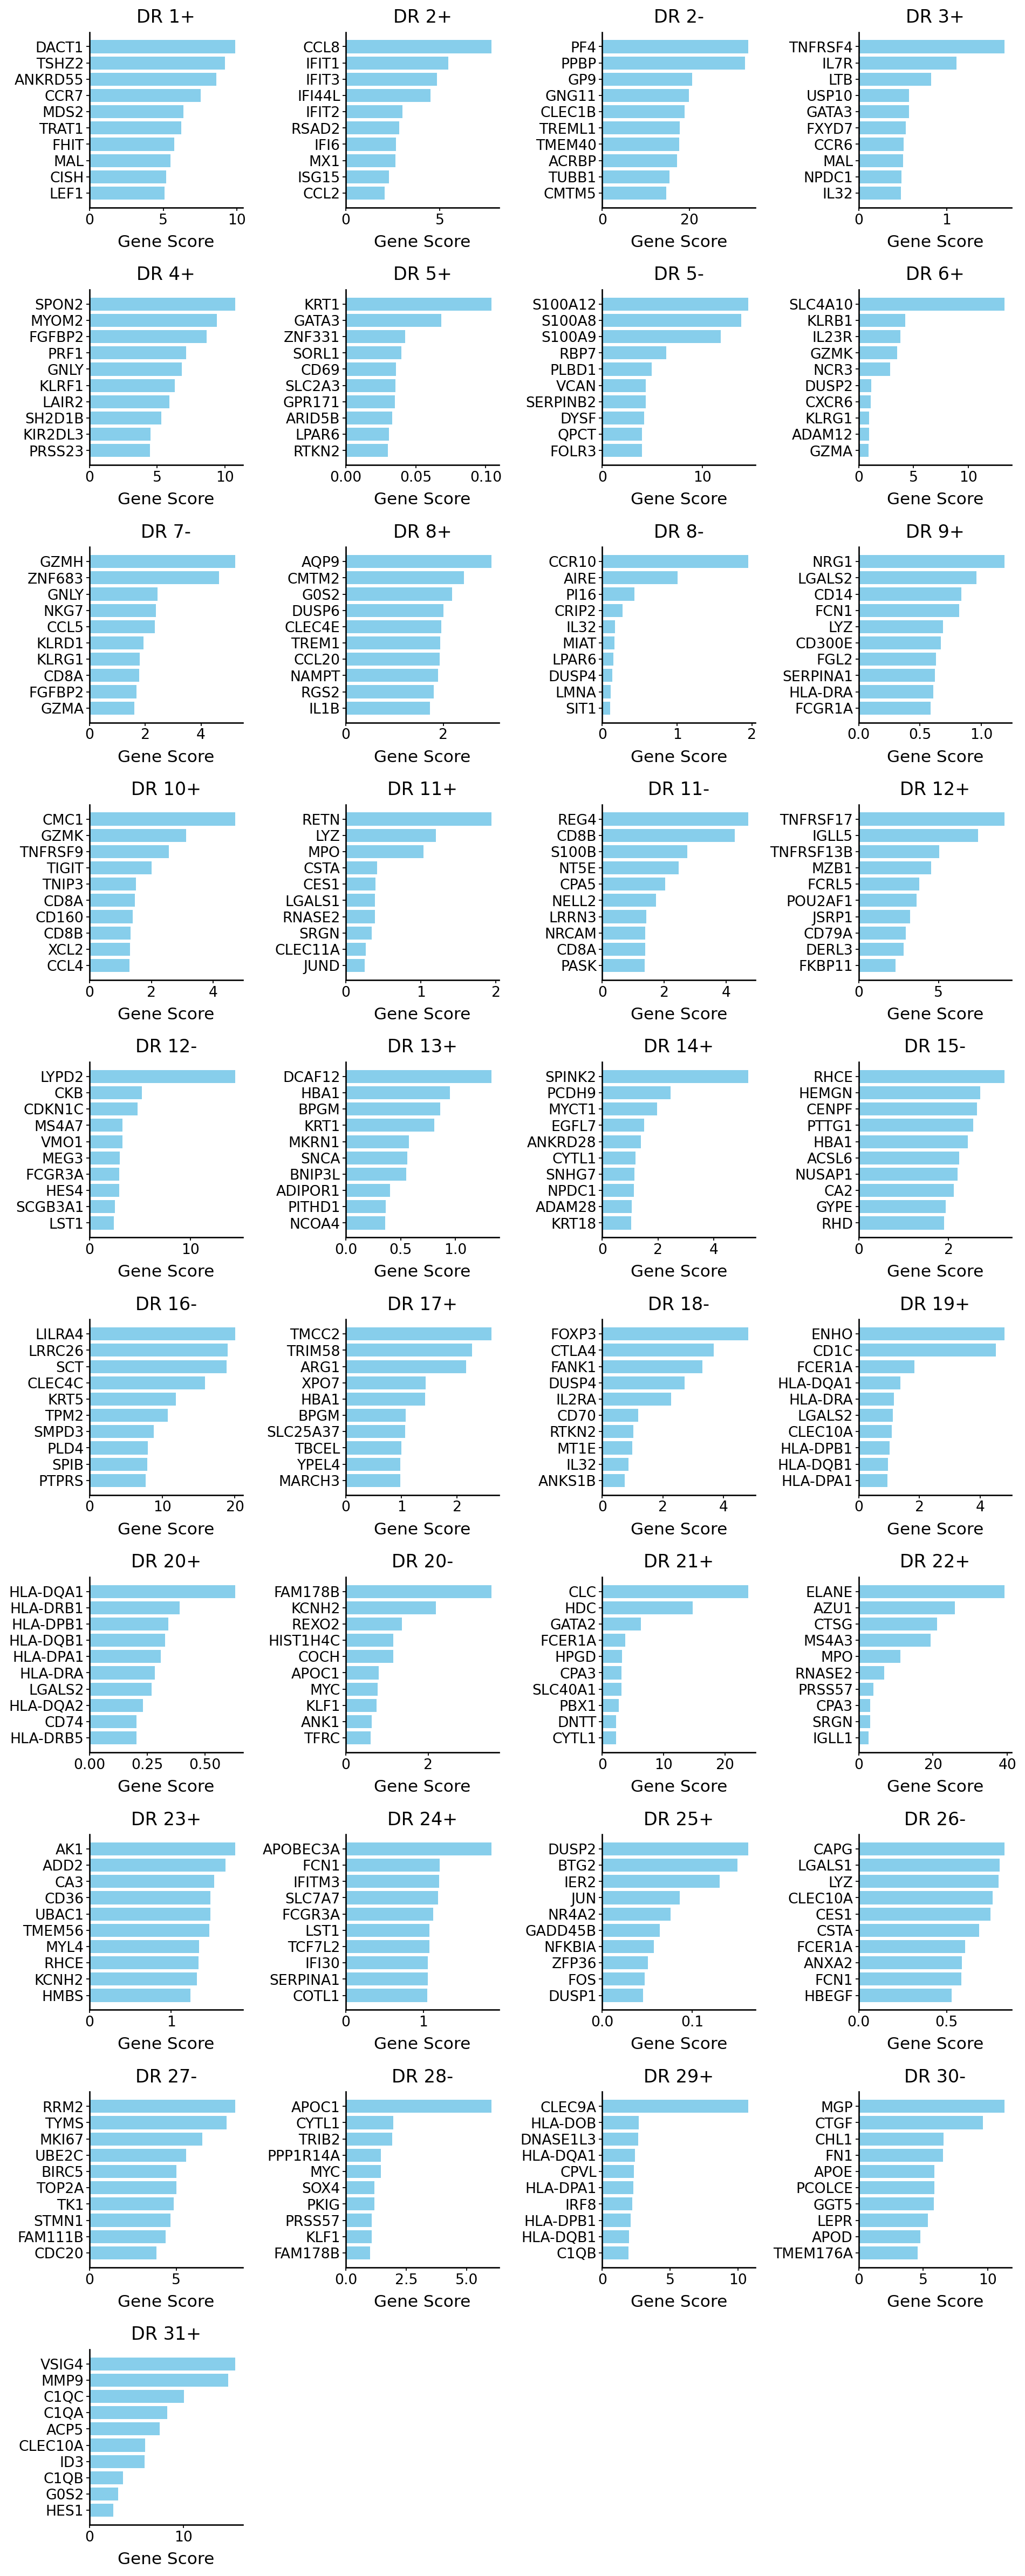

######## DRVI2 ########
################################################
################################################
################################################
################################################
################################################


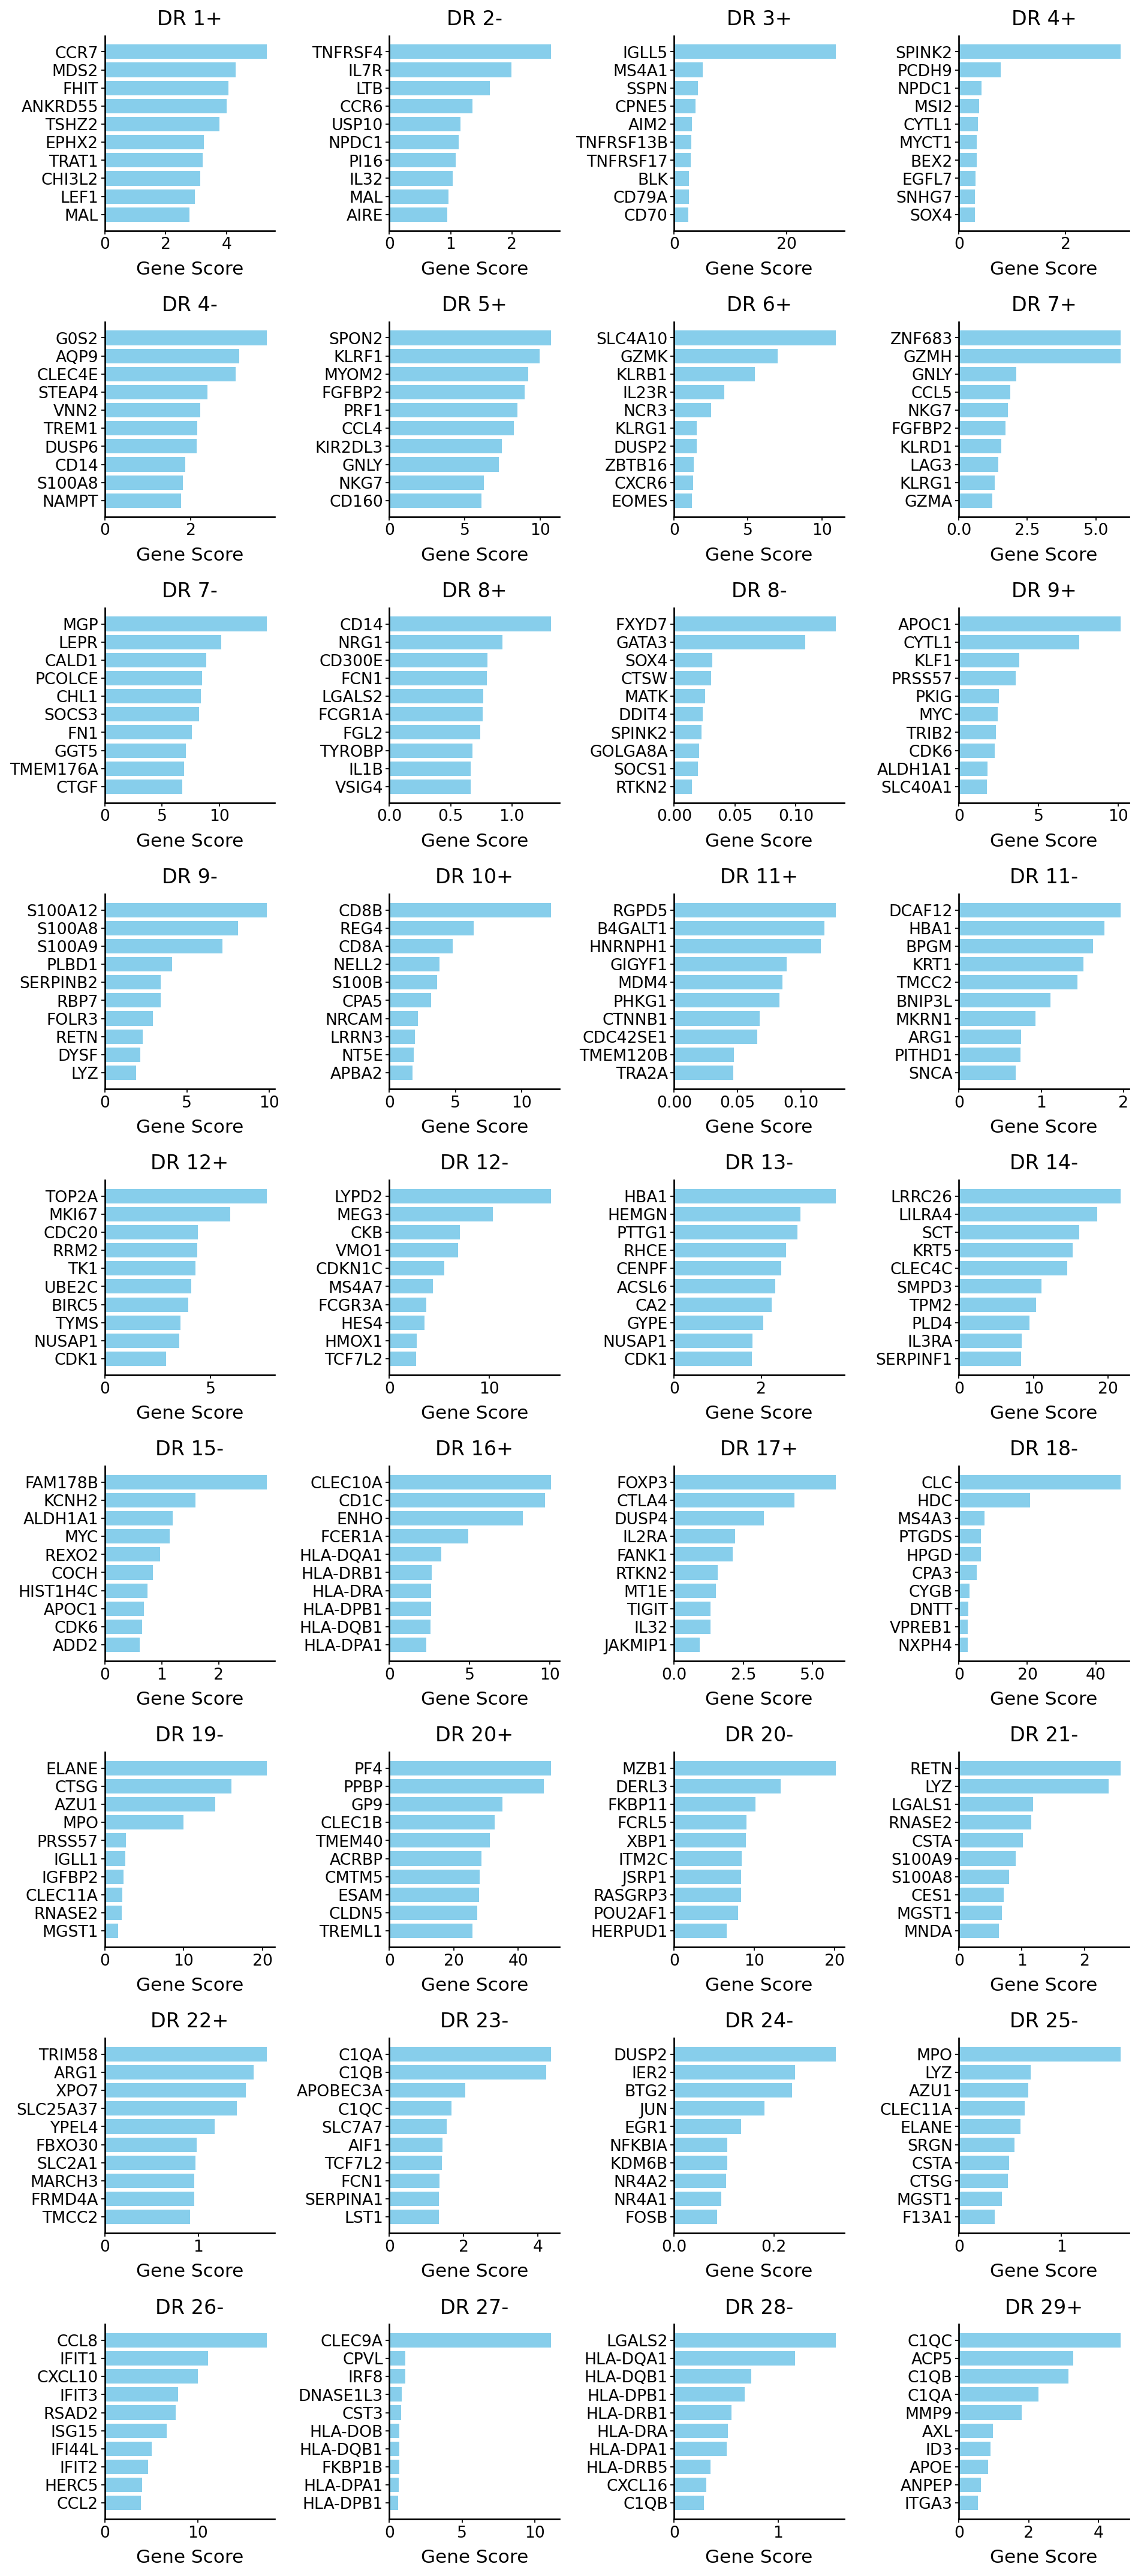

######## PCA ########
################################################
################################################
################################################
################################################
################################################


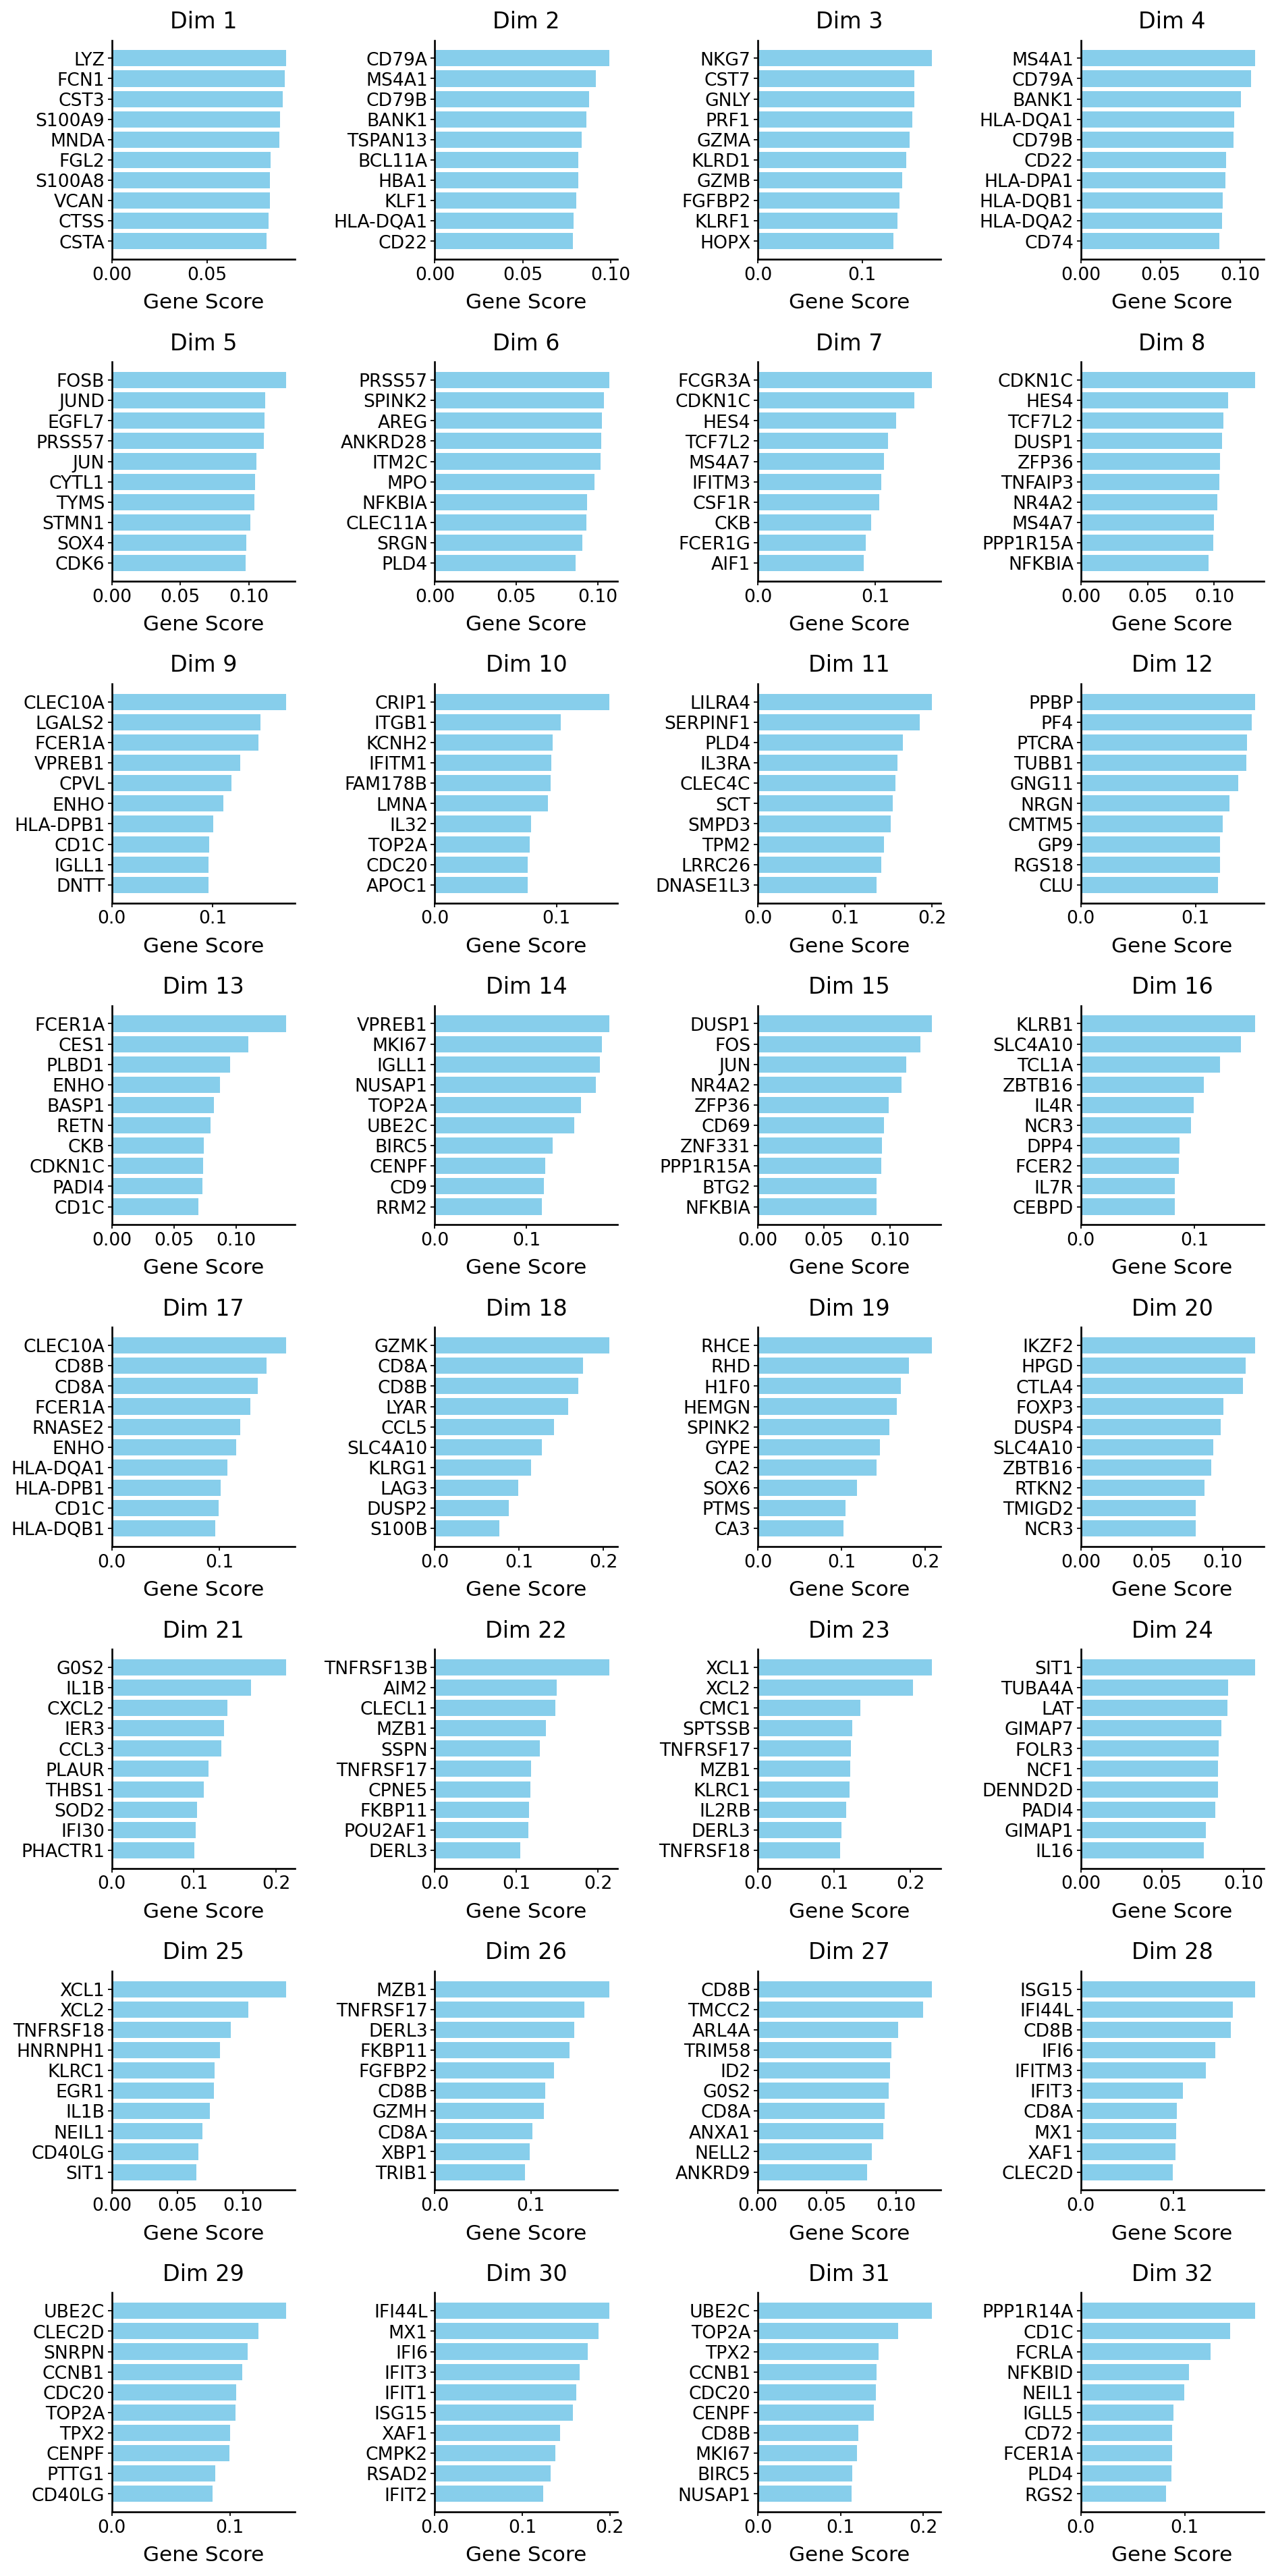

######## ICA ########
################################################
################################################
################################################
################################################
################################################


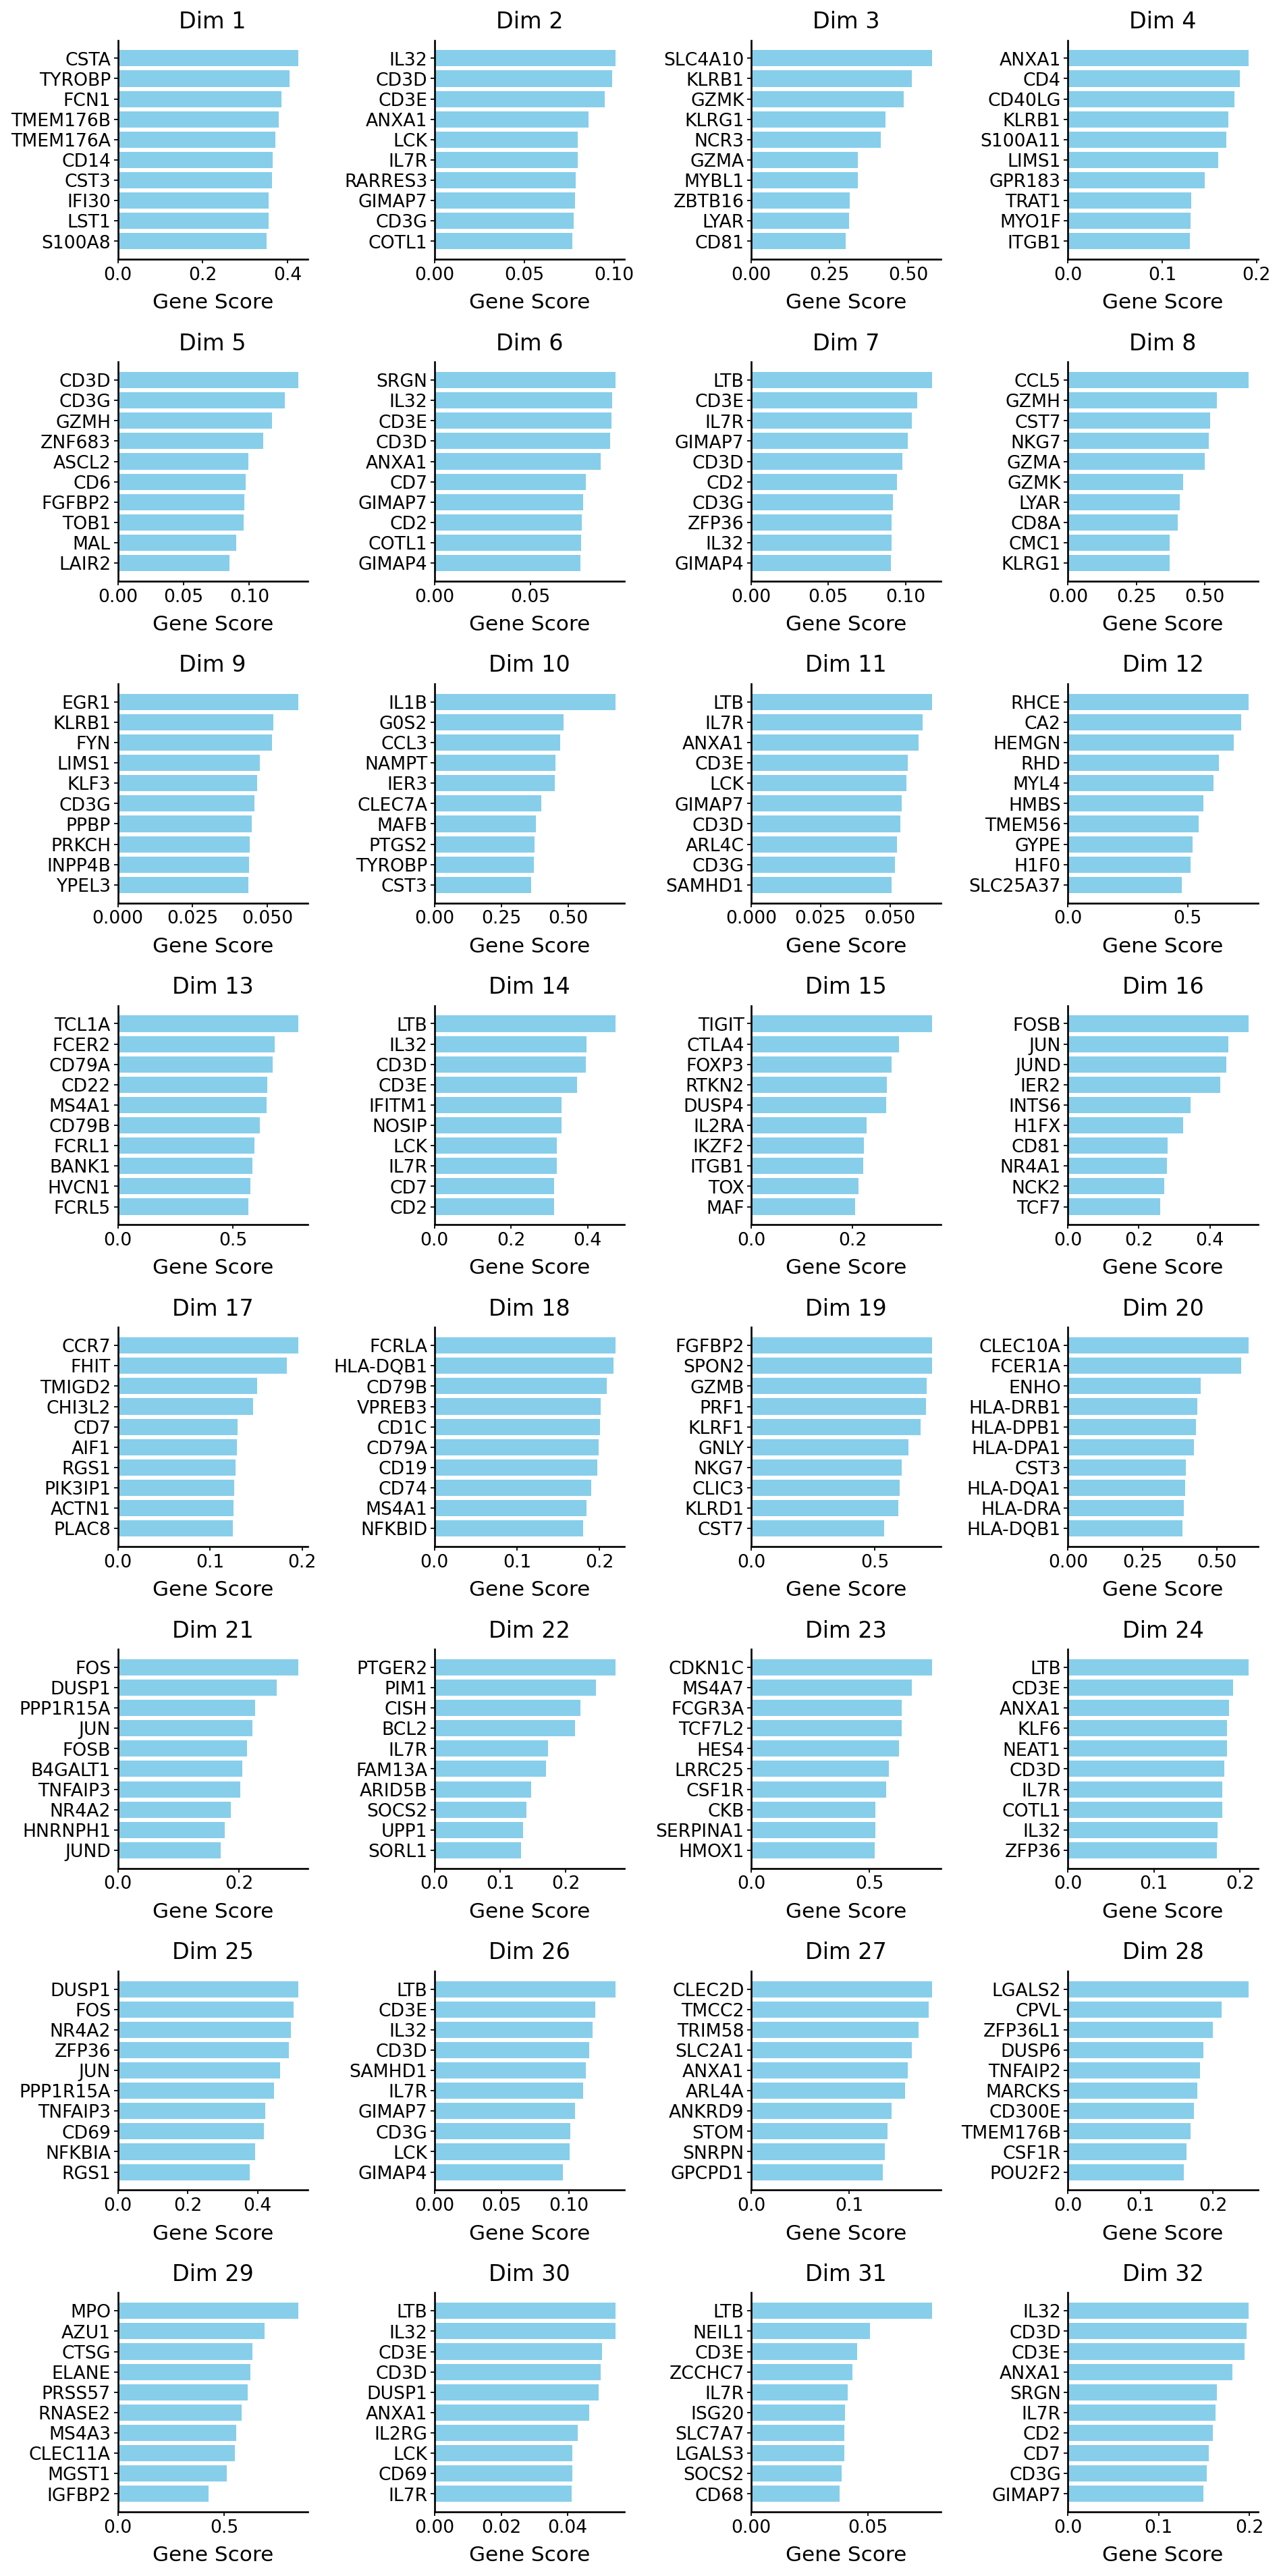

######## LIGER ########
################################################
################################################
################################################
################################################
################################################


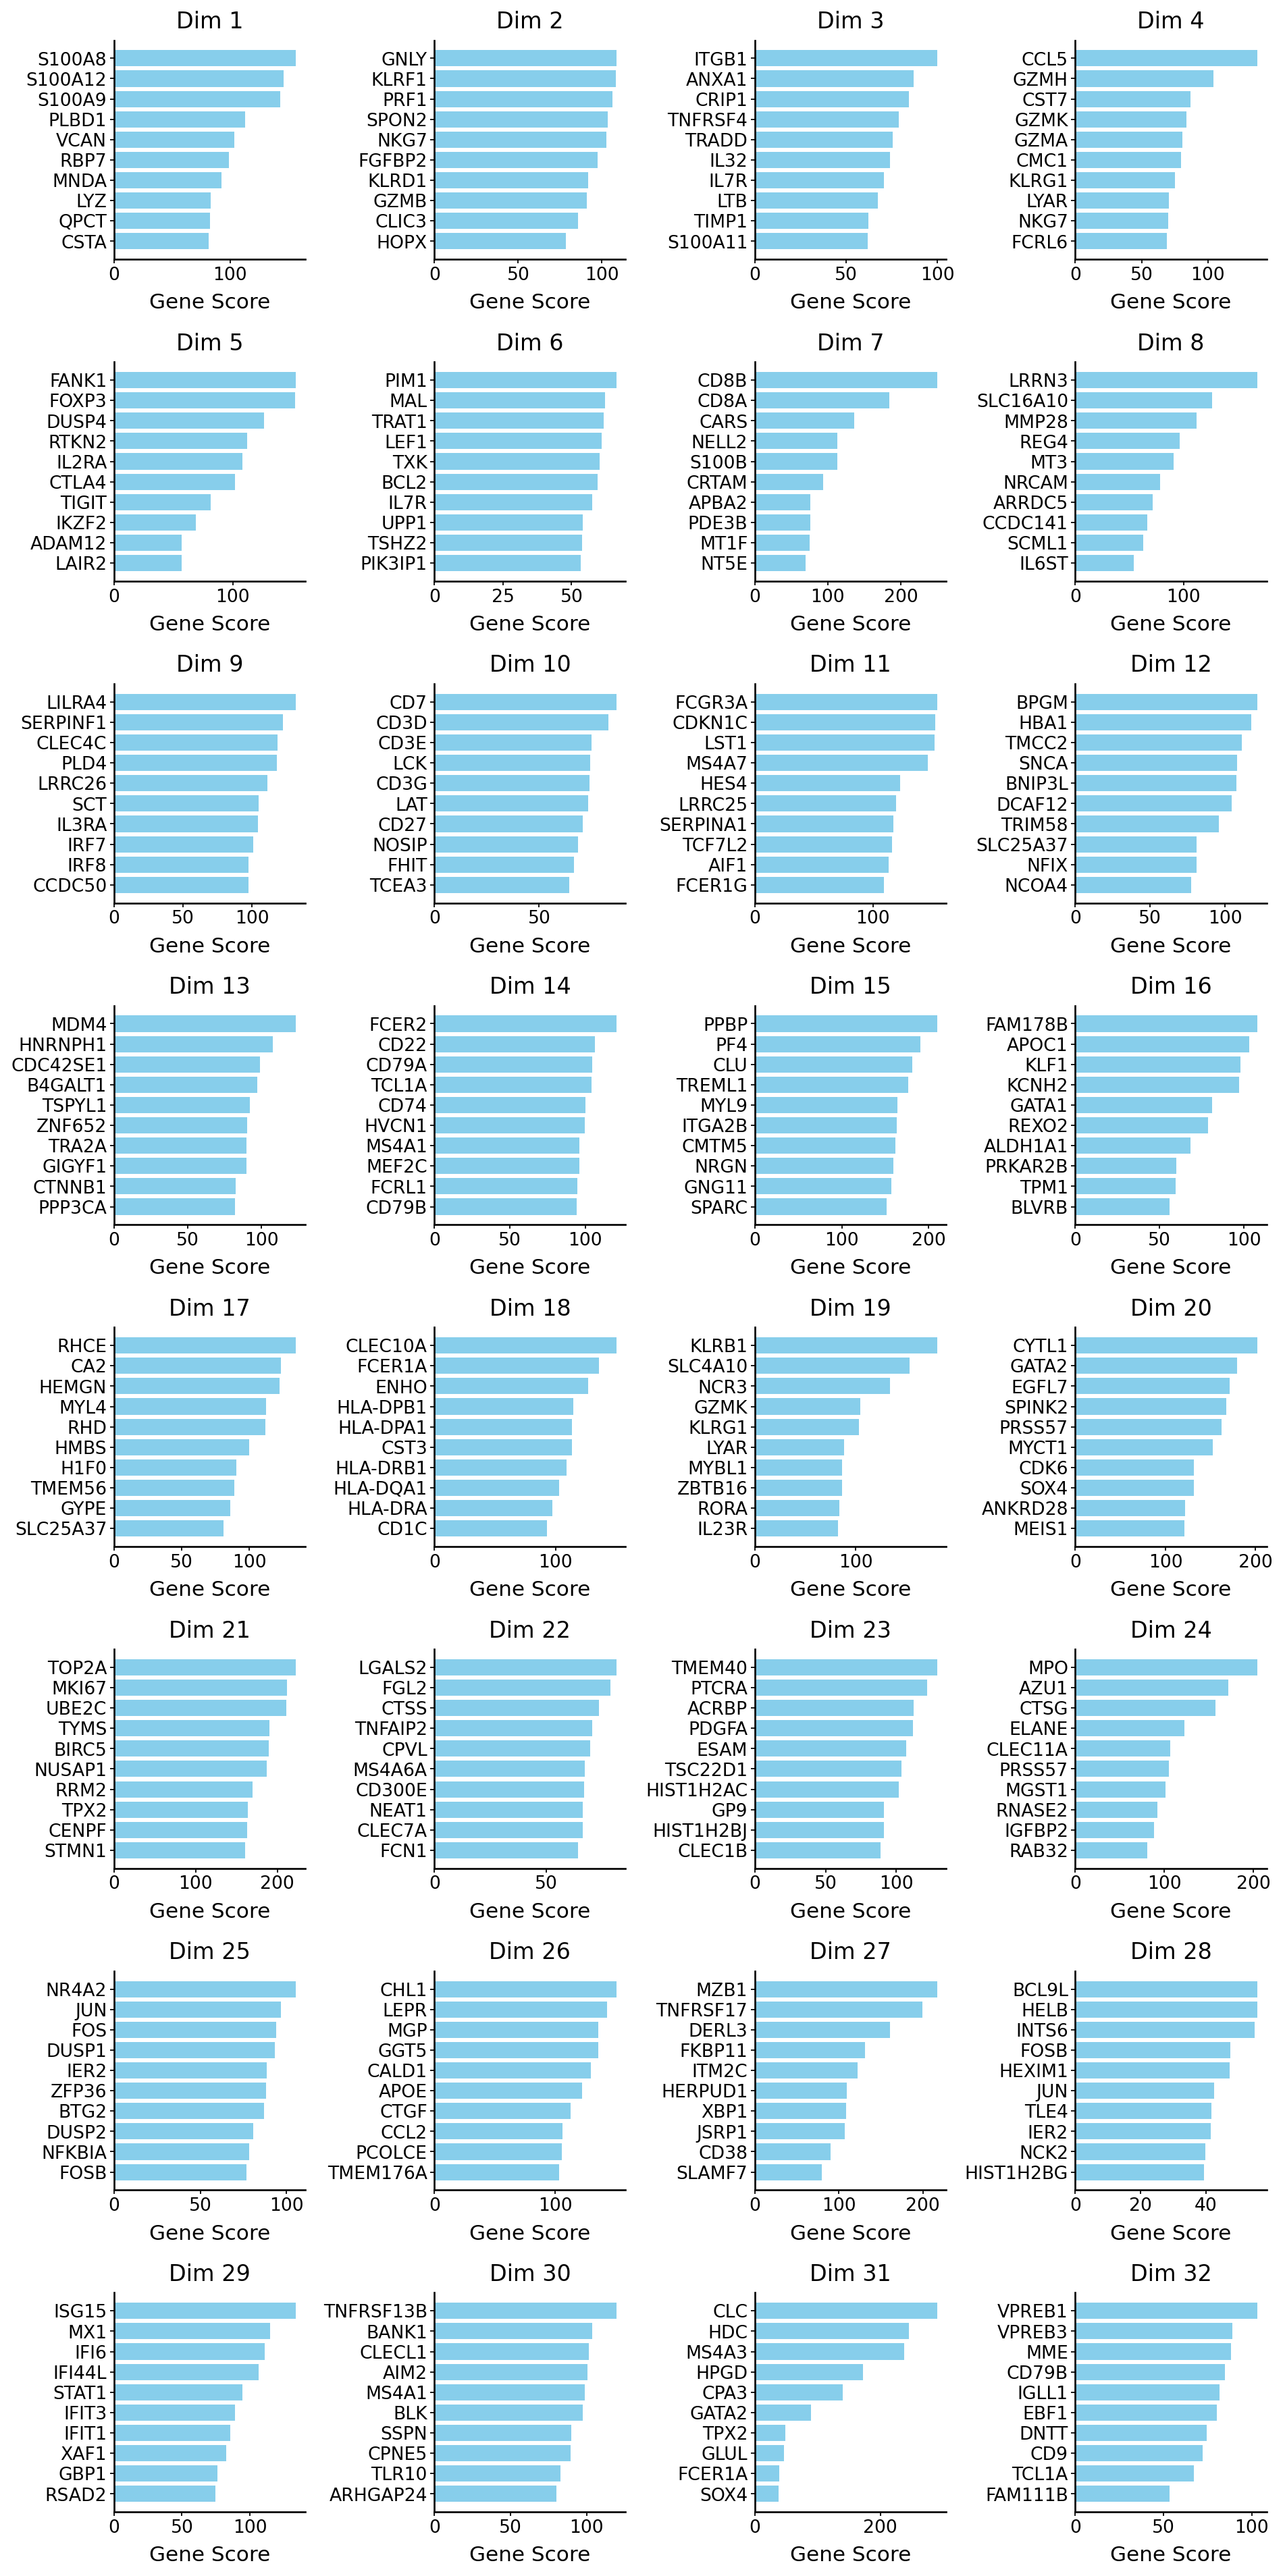

######## MOFA ########
################################################
################################################
################################################
################################################
################################################


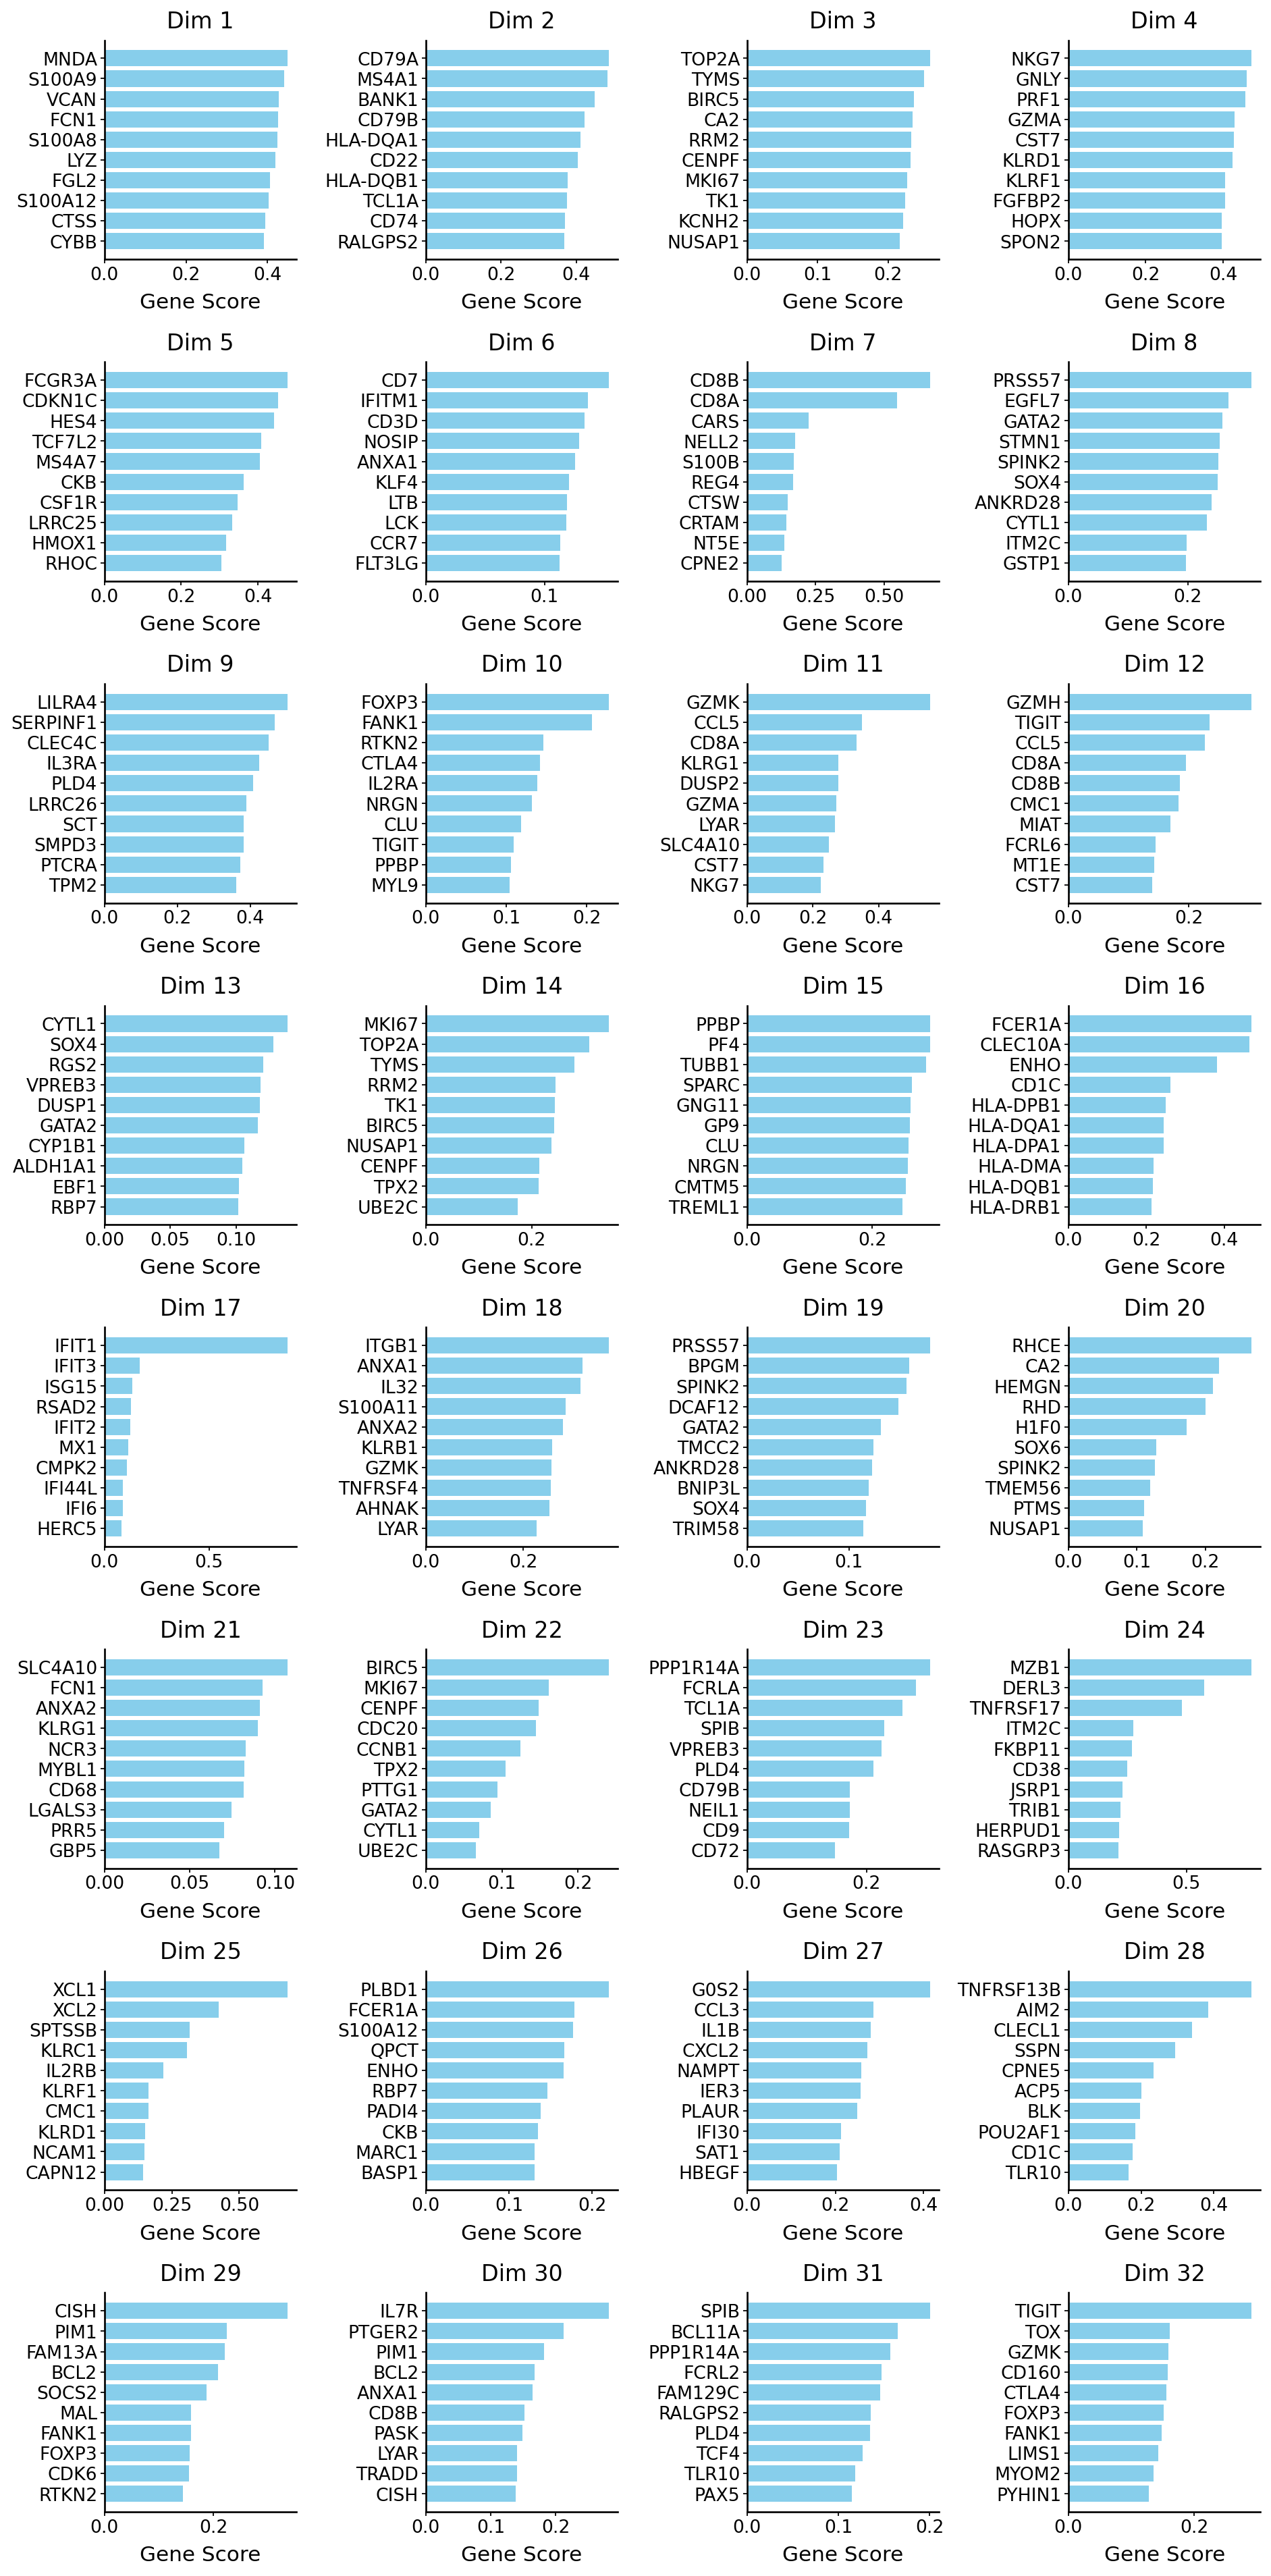

######## scETM ########
################################################
################################################
################################################
################################################
################################################


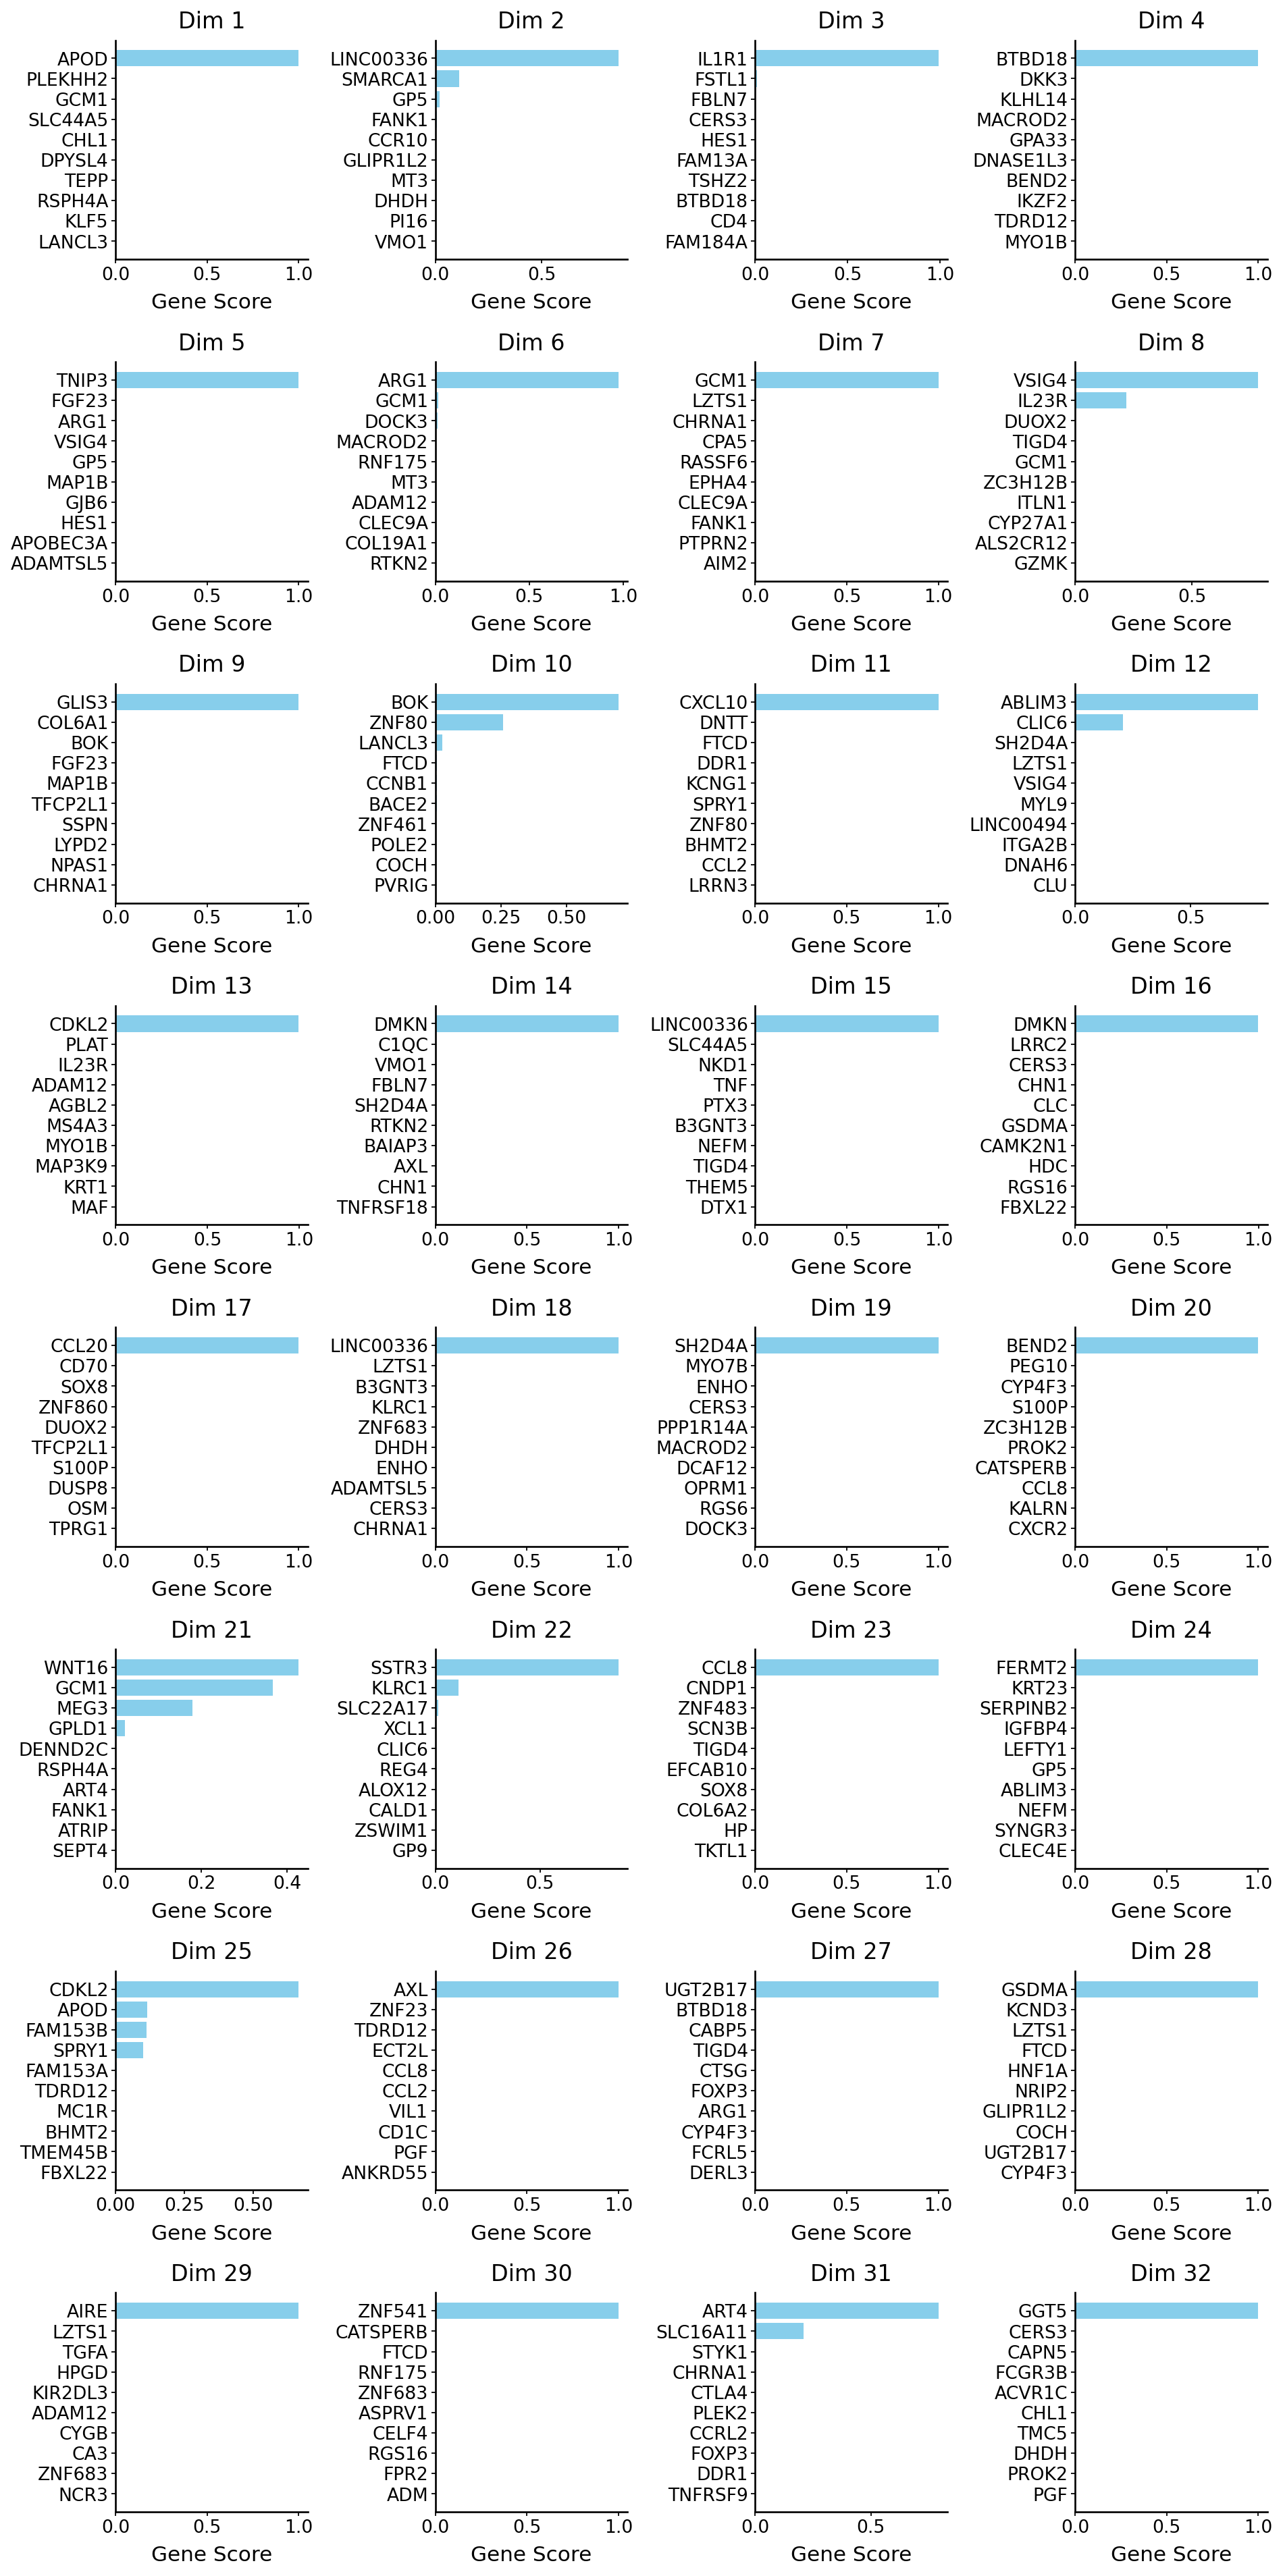

In [39]:
for method_name, embed in embeds.items():
    print(f"######## {method_name} ########")
    print("\n".join(["################################################"]*5))
    int_df = int_dfs[method_name]
    plot_interpretability_scores(int_df)

In [24]:
def plot_best_dims_interpretability(
    interpretability_dfs, 
    most_relevant_dim, 
    n_top_genes=10, 
    figsize_multiplier=(2.5, 2),
    w_pad=0.1,
    color="skyblue",
    show=True,
    drvi_direction='+',
    model_directions=None,
    ncols=3,
):
    """
    Plots the top genes for the most relevant dimension across different methods.
    
    Args:
        interpretability_dfs (dict): Dictionary mapping method names to their 
                                     interpretability DataFrames (genes x dimensions).
        most_relevant_dim (dict): Dictionary mapping method names to their 
                                  most relevant dimension name.
        n_top_genes (int): Number of top genes to display per method.
        figsize_multiplier (tuple): Base width and height per subplot.
        color (str): Bar color.
        show (bool): Whether to display the plot immediately.
    """
    
    n_methods = len(most_relevant_dim)
    if n_methods == 0:
        print("No methods provided to plot.")
        return None

    actual_ncols = min(ncols, n_methods)
    n_rows = (n_methods + actual_ncols - 1) // actual_ncols

    # Create a grid based on ncols and n_rows
    fig, axes = plt.subplots(
        n_rows, 
        actual_ncols, 
        figsize=(figsize_multiplier[0] * actual_ncols, figsize_multiplier[1] * n_rows),
        squeeze=False
    )
    
    # Flatten the axes array for easy iteration
    axes_flat = axes.flatten()
    
    for ax, (method_name, best_dim) in zip(axes_flat, most_relevant_dim.items()):
        if method_name == 'DRVI':
            best_dim = best_dim + drvi_direction
        
        # Check if we have interpretability data for this method
        if method_name not in interpretability_dfs:
            ax.text(0.5, 0.5, f"No Interpretability\nData for\n{method_name}", 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(method_name)
            ax.axis('off')
            continue
            
        interp_df = interpretability_dfs[method_name]
        
        # Check if the best dimension exists in the interpretability data
        if best_dim not in interp_df.columns:
             ax.text(0.5, 0.5, f"Dim '{best_dim}'\nnot found in\n{method_name}", 
                    ha='center', va='center', transform=ax.transAxes)
             ax.set_title(method_name)
             ax.axis('off')
             continue

        # Determine sorting direction and display name
        ascending_sort = False
        display_dim = str(best_dim)
        score_multiplier = 1
        
        if model_directions and method_name in model_directions:
            direction = model_directions[method_name]
            if direction == '+':
                ascending_sort = False
                display_dim = f"{best_dim}+"
            elif direction == '-':
                ascending_sort = True
                display_dim = f"{best_dim}-"
                score_multiplier = -1

        # Extract the specific dimension and sort
        dim_scores = interp_df[best_dim]
        top_indices = dim_scores.sort_values(ascending=ascending_sort)[:n_top_genes]
        top_indices = top_indices * score_multiplier
        
        if len(top_indices) > 0:
            ax.barh(top_indices.index, top_indices.values, color=color)
            # ax.set_xlabel("Gene Score")
            ax.set_xlabel(None)
            ax.set_title(f"{method_name} ({display_dim})")
            ax.invert_yaxis()
            ax.grid(False)
        else:
             ax.text(0.5, 0.5, "No genes found", ha='center', va='center')
             ax.set_title(f"{method_name} ({display_dim})")

    # Delete any extra empty subplots if n_methods isn't a perfect multiple of ncols
    for ax in axes_flat[n_methods:]:
        fig.delaxes(ax)

    plt.tight_layout(w_pad=w_pad)
    
    if show:
        plt.show()
    else:
        return fig

In [25]:
def plot_benchmark_scatter(
    sorted_embeds, 
    most_relevant_dim, 
    smi_scores, 
    y_col, 
    color_col, 
    sort_cols, 
    is_continuous=True, 
    cmap='viridis',
    y_label=None,
    **kwargs
):
    """
    Generates a combined row of scatter plots for different benchmarking methods, 
    handling both continuous (colorbar) and discrete (legend) hue coloring.
    """
    n_methods = len(sorted_embeds)
    
    if is_continuous:
        # GridSpec layout to cleanly accommodate the dedicated colorbar area
        fig = plt.figure(figsize=(3 * n_methods, 3.5), constrained_layout=True)
        gs = gridspec.GridSpec(1, n_methods + 1, figure=fig, width_ratios=[1] * n_methods + [0.05], wspace=0.12)
    else:
        # Standard subplots for discrete legends
        fig, axes_arr = plt.subplots(1, n_methods, figsize=(3.5 * n_methods + 0.8, 3.5), sharey=True, squeeze=False)
        
    axes = []
    for i in range(n_methods):
        if is_continuous:
            if i == 0:
                ax = fig.add_subplot(gs[0, i])
            else:
                ax = fig.add_subplot(gs[0, i], sharey=axes[0])
                ax.tick_params(labelleft=False) # Safely hide y-axis numbers for inner plots
        else:
            ax = axes_arr[0, i]
        axes.append(ax)

    if is_continuous:
        cax = fig.add_subplot(gs[0, -1])

    for i, (raw_method_name, embed) in enumerate(sorted_embeds):
        method_name = pretify_method_name(raw_method_name)
        
        # Safely fetch dimension and score matching either raw or prettified name
        best_dim = most_relevant_dim.get(raw_method_name, most_relevant_dim.get(method_name))
        smi_score = smi_scores.get(raw_method_name, smi_scores.get(method_name))
        
        ax_scatter = axes[i]
        
        # Format DataFrame
        embed_df = embed.copy()
        embed_df.var.set_index('title', inplace=True)
        embed_df = embed_df.to_df()
        embed_df = pd.concat([embed_df, embed.obs], axis=1)
        
        # Sort values to ensure highlighted/brightest points are drawn last (on top)
        embed_df.sort_values(by=sort_cols, ascending=[True] * len(sort_cols), inplace=True)
        
        if is_continuous:
            scatter = ax_scatter.scatter(
                embed_df[best_dim], 
                embed_df[y_col], 
                c=embed_df[color_col], 
                cmap=cmap,
                edgecolor=None,
                rasterized=True,
                **kwargs
            )
        else:
            sns.scatterplot(
                data=embed_df, 
                x=best_dim, 
                y=y_col, 
                hue=color_col, 
                edgecolor=None,
                rasterized=True,
                ax=ax_scatter,
                legend=(i == n_methods - 1), # Only show legend on the last subplot
                **kwargs
            )
        
        # Include dimension name in title only for discrete plots as per original formatting
        title = f"{method_name} ({best_dim})"
        title = None
        ax_scatter.set_title(title)
        ax_scatter.grid(False) 
        ax_scatter.set_xlabel(best_dim) 
        
        # Handle Y-axis labels
        if i == 0:
            ax_scatter.set_ylabel(y_label if y_label else f"{y_col} score")
        else:
            ax_scatter.set_ylabel("") 
        
        # Add SMI score inside the plot area
        ax_scatter.text(0.05, 0.95, f"SMI: {smi_score:.2f}", 
                transform=ax_scatter.transAxes, 
                fontsize=16,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='none'))

    if is_continuous and n_methods > 0:
        cbar = fig.colorbar(scatter, cax=cax)
        cbar.set_label(color_col)
    elif not is_continuous and n_methods > 0:
        last_ax = axes[-1]
        if last_ax.legend_ is not None:
            sns.move_legend(last_ax, "upper left", bbox_to_anchor=(1.05, 1))
            
            # Fix legend dot sizes
            for handle in last_ax.legend_.legend_handles:
                if hasattr(handle, 'set_sizes'):
                    handle.set_sizes([50])        
                elif hasattr(handle, 'set_markersize'):
                    handle.set_markersize(8)      
                handle.set_alpha(1.0)              

In [37]:
def calc_normalized_mi(a, b, n_bins=10):
    # Bin both vectors (labels=False returns integer bin indices)
    a_binned = pd.cut(a, bins=n_bins, labels=False)
    b_binned = pd.cut(b, bins=n_bins, labels=False)
    
    # Calculate Mutual Information MI(a, b)
    mi = mutual_info_score(a_binned, b_binned)
    
    # Calculate Entropy H(b) using the self-mutual information trick
    h_b = mutual_info_score(b_binned, b_binned)
    
    # Return normalized MI (handle edge case where b has zero variance/entropy)
    if h_b == 0:
        return 0.0
        
    return mi / h_b

## Compare identification capabilities for DC1

In [26]:
adata_full = sc.read_h5ad("/home/icb/amirali.moinfar/data/prepared/immune_all_human/immune_all_genes.h5ad")

In [27]:
canonical_markers = ["CLEC9A", 'CADM1', 'BATF3', 'THBD']

In [28]:
sc.tl.score_genes(adata_full, canonical_markers, score_name='DC1', layer='lognorm')
adata_full.obs['is DC1'] = adata_full.obs['DC1'] > 0.5
adata_full.obs['is DC1'] = adata_full.obs['is DC1'].astype('category')

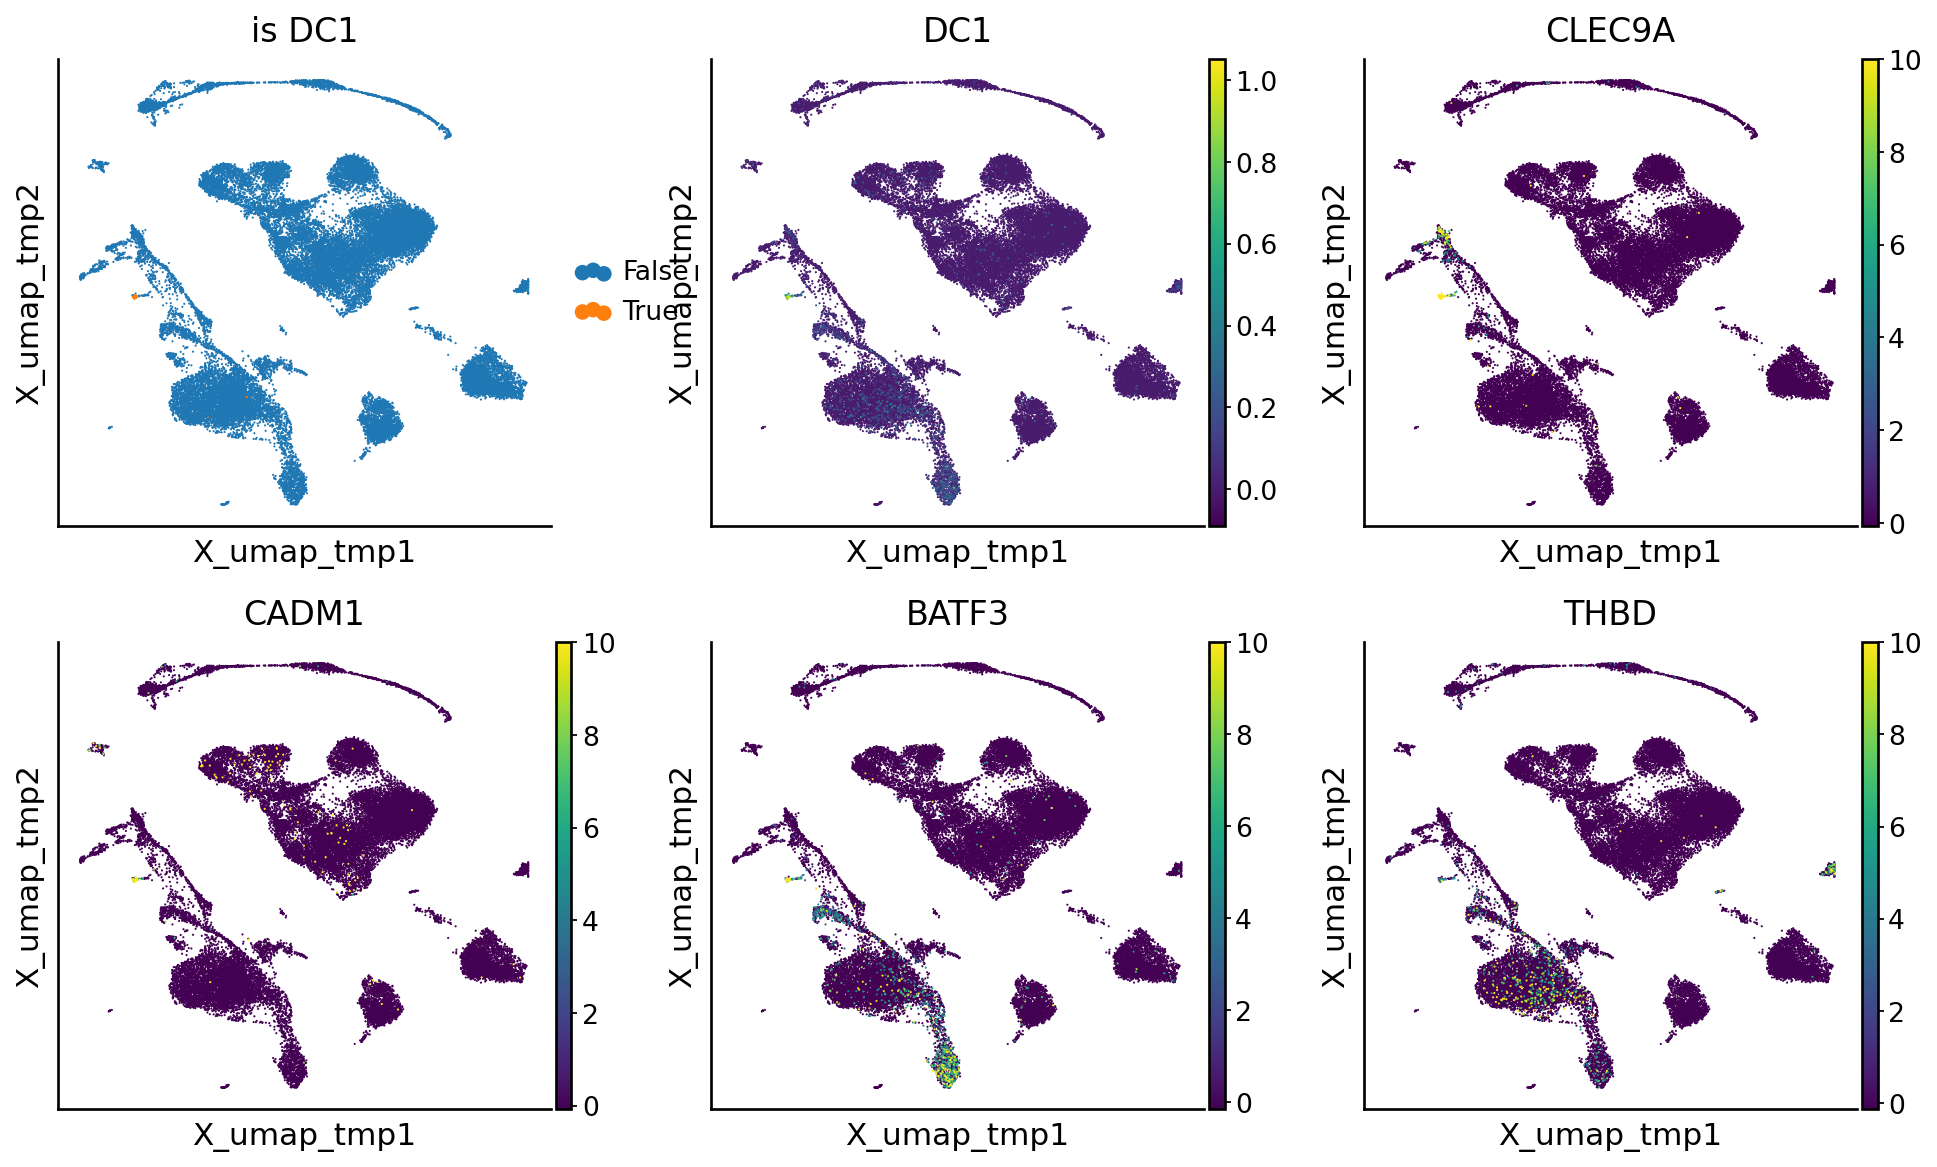

In [29]:
adata_full.obsm['X_umap_tmp'] = embeds['DRVI'][adata.obs.index].obsm['X_umap']
sc.pl.embedding(adata_full, "X_umap_tmp", color=['is DC1', 'DC1'] + canonical_markers, ncols=3)

In [30]:
most_relevant_dim_dc1 = {}
smi_scores_dc1 = {} # Store scores for the plotting cell

# Sort embeds according to the predefined global order using prettified names
def get_sort_key(item):
    pretty_name = pretify_method_name(item[0])
    if pretty_name in methods_general_order:
        return methods_general_order.index(pretty_name)
    return float('inf')

sorted_embeds = sorted(embeds.items(), key=get_sort_key)

for raw_method_name, embed in sorted_embeds:
    method_name = pretify_method_name(raw_method_name)
    print(method_name)
    
    embed.obs['DC1'] = adata_full.obs['DC1']
    embed.obs['is DC1'] = adata_full.obs['is DC1']
    
    bench = DiscreteDisentanglementBenchmark(
        embed.X, discrete_target=embed.obs['is DC1'], one_hot_target=None,
        dim_titles=embed.var['title']
    )
    bench.evaluate()
    
    scores = bench.get_results_details()['SMI'][True].sort_values(ascending=False)
    best_dim = scores.index[0]
    most_relevant_dim_dc1[method_name] = best_dim
    smi_scores_dc1[method_name] = scores[0]
    print(best_dim, scores[0])

DRVI
DR 29 0.7502716477054846
scETM
Dim 26 0.2719252746346148
LIGER
Dim 18 0.46089735340794696
MOFA
Dim 16 0.38178751610852807
ICA
Dim 20 0.43540131726262044
PCA
Dim 1 0.36363548700265613


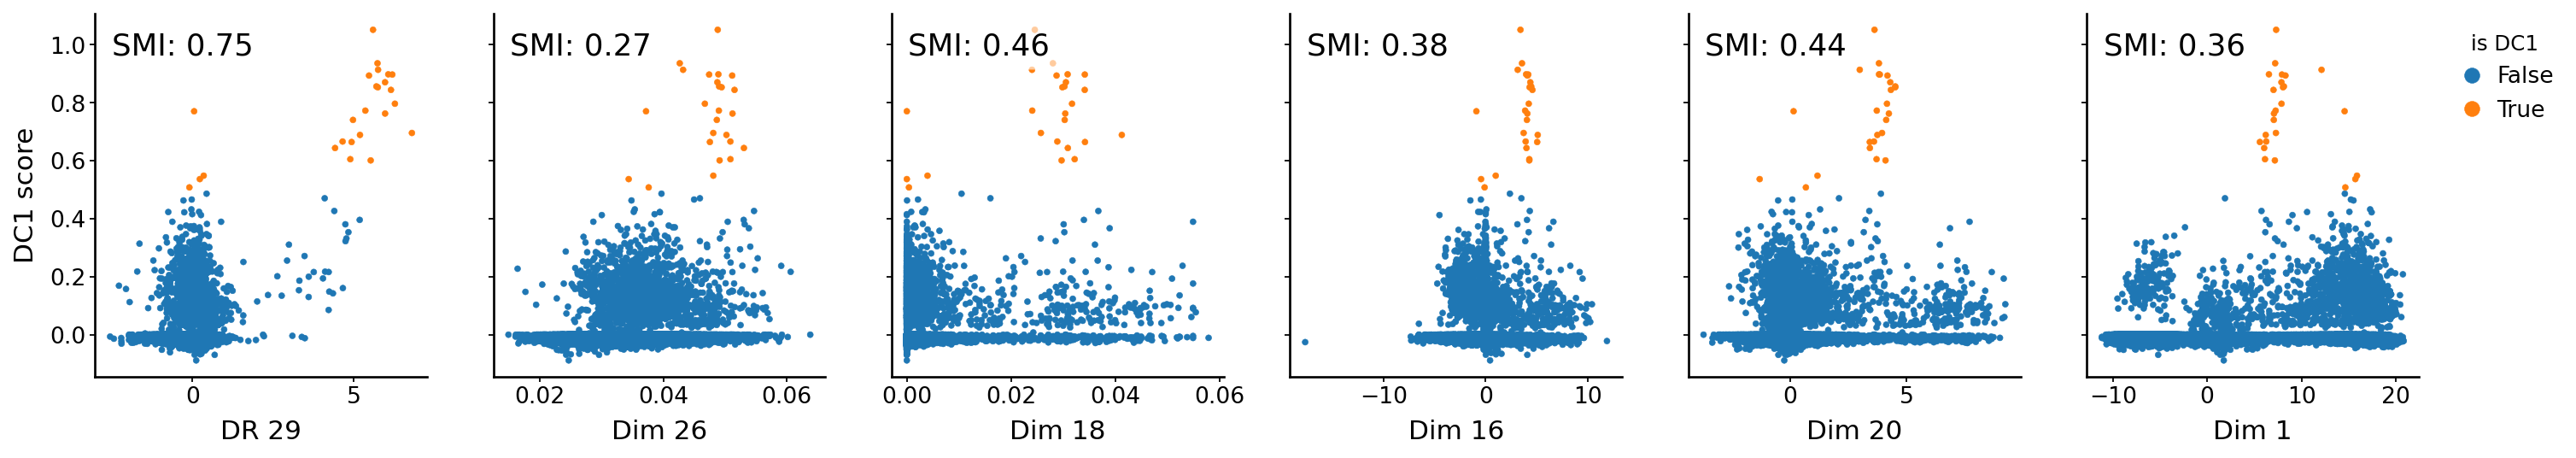

In [31]:
plot_benchmark_scatter(
    sorted_embeds=sorted_embeds,
    most_relevant_dim=most_relevant_dim_dc1,
    smi_scores=smi_scores_dc1,
    y_col='DC1',
    color_col='is DC1',
    sort_cols=['is DC1'], # Sort so 'True' values are plotted on top
    is_continuous=False,
    y_label="DC1 score",
    s=10,
    alpha=1.0
)
# Save as a single combined PDF
plt.savefig(output_dir / "combined_dc1_scatter.pdf", bbox_inches='tight', dpi=300)
plt.show()

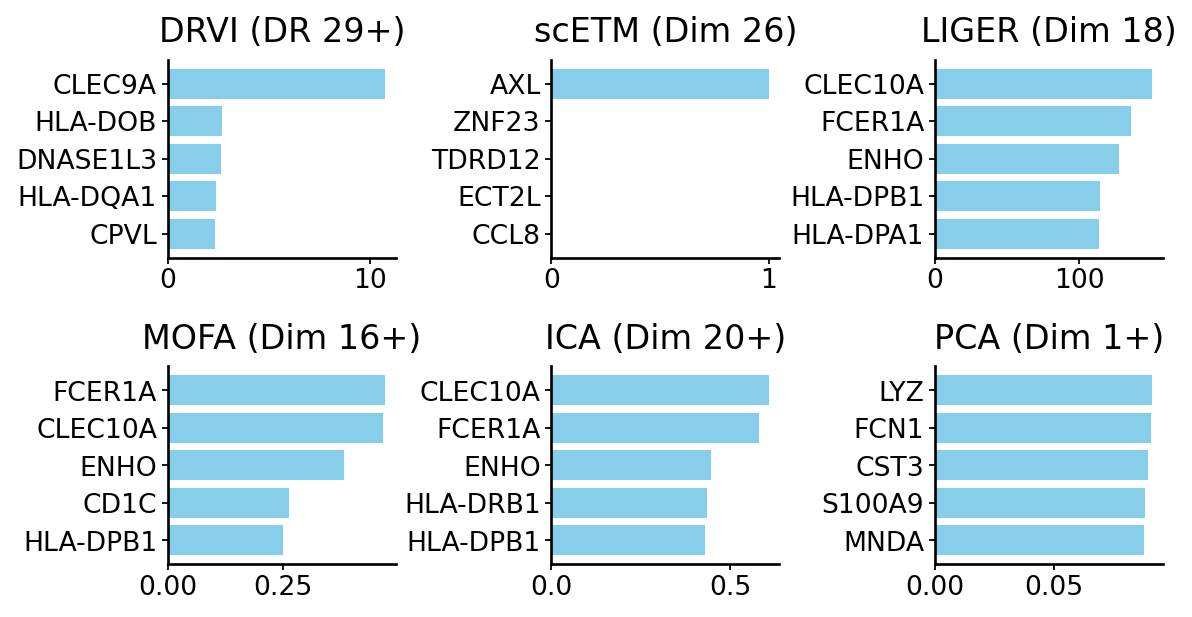

In [32]:
fig = plot_best_dims_interpretability(
        interpretability_dfs=int_dfs,
        most_relevant_dim=most_relevant_dim_dc1,
        n_top_genes=5,
        show=False,  # Changed to False so it returns the figure
        drvi_direction='+',
        model_directions={
            'ICA': '+',
            'PCA': '+',
            'MOFA': '+',
        }
    )

fig.savefig(output_dir / "interpretability_comparison_dc1.pdf", bbox_inches='tight', dpi=300)

## Interferone Alpha (type I)

In [39]:
HALLMARK_INTERFERON_ALPHA_RESPONSE = ["ADAR", "B2M", "BATF2", "BST2", "C1S", "CASP1", "CASP8", "CCRL2", "CD47", "CD74", "CMPK2", "CNP", "CSF1", "CXCL10", "CXCL11", "DDX60", "DHX58", "EIF2AK2", "ELF1", "EPSTI1", "FAM125A", "FAM46A", "FTSJD2", "GBP2", "GBP4", "GMPR", "HERC6", "HLA", "IFI27", "IFI30", "IFI35", "IFI44", "IFI44L", "IFIH1", "IFIT2", "IFIT3", "IFITM1", "IFITM2", "IFITM3", "IL15", "IL4R", "IL7", "IRF1", "IRF2", "IRF7", "IRF9", "ISG15", "ISG20", "LAMP3", "LAP3", "LGALS3BP", "LPAR6", "LY6E", "MOV10", "MX1", "NCOA7", "NMI", "NUB1", "OAS1", "OASL", "OGFR", "PARP12", "PARP14", "PARP9", "PLSCR1", "PNPT1", "PRIC285", "PROCR", "PSMA3", "PSMB8", "PSMB9", "PSME1", "PSME2", "RIPK2", "RNF31", "RSAD2", "RTP4", "SAMD9", "SAMD9L", "SELL", "SLC25A28", "SP110", "STAT2", "TAP1", "TDRD7", "TMEM140", "TRAFD1", "TRIM14", "TRIM21", "TRIM25", "TRIM26", "TRIM5", "TXNIP", "UBA7", "UBE2L6", "USP18", "WARS"]
HALLMARK_INTERFERON_Gamma_RESPONSE = ["ADAR", "APOL6", "ARID5B", "ARL4A", "AUTS2", "B2M", "BANK1", "BATF2", "BPGM", "BST2", "BTG1", "C1R", "C1S", "CASP1", "CASP3", "CASP4", "CASP7", "CASP8", "CCL2", "CCL5", "CCL7", "CD274", "CD38", "CD40", "CD69", "CD74", "CD86", "CDKN1A", "CFB", "CFH", "CIITA", "CMKLR1", "CMPK2", "CSF2RB", "CXCL10", "CXCL11", "CXCL9", "DDX58", "DDX60", "DHX58", "EIF2AK2", "EIF4E3", "EPSTI1", "FAS", "FCGR1A", "FGL2", "FPR1", "FTSJD2", "GBP4", "GBP6", "GCH1", "GPR18", "GZMA", "HERC6", "HIF1A", "HLA", "HLA", "HLA", "HLA", "HLA", "HLA", "ICAM1", "IDO1", "IFI27", "IFI30", "IFI35", "IFI44", "IFI44L", "IFIH1", "IFIT1", "IFIT2", "IFIT3", "IFITM2", "IFITM3", "IFNAR2", "IL10RA", "IL15", "IL15RA", "IL18BP", "IL2RB", "IL4R", "IL6", "IL7", "IRF1", "IRF2", "IRF4", "IRF5", "IRF7", "IRF8", "IRF9", "ISG15", "ISG20", "ISOC1", "ITGB7", "JAK2", "KLRK1", "LAP3", "LATS2", "LCP2", "LGALS3BP", "LY6E", "LYSMD2", "MARCH1", "METTL7B", "MT2A", "MTHFD2", "MVP", "MX1", "MX2", "MYD88", "NAMPT", "NCOA3", "NFKB1", "NFKBIA", "NLRC5", "NMI", "NOD1", "NUP93", "OAS2", "OAS3", "OASL", "OGFR", "P2RY14", "PARP12", "PARP14", "PDE4B", "PELI1", "PFKP", "PIM1", "PLA2G4A", "PLSCR1", "PML", "PNP", "PNPT1", "PRIC285", "PSMA2", "PSMA3", "PSMB10", "PSMB2", "PSMB8", "PSMB9", "PSME1", "PSME2", "PTGS2", "PTPN1", "PTPN2", "PTPN6", "RAPGEF6", "RBCK1", "RIPK1", "RIPK2", "RNF213", "RNF31", "RSAD2", "RTP4", "SAMD9L", "SAMHD1", "SECTM1", "SELP", "SERPING1", "SLAMF7", "SLC25A28", "SOCS1", "SOCS3", "SOD2", "SP110", "SPPL2A", "SRI", "SSPN", "ST3GAL5", "ST8SIA4", "STAT1", "STAT2", "STAT3", "STAT4", "TAP1", "TAPBP", "TDRD7", "TNFAIP2", "TNFAIP3", "TNFAIP6", "TNFSF10", "TOR1B", "TRAFD1", "TRIM14", "TRIM21", "TRIM25", "TRIM26", "TXNIP", "UBE2L6", "UPP1", "USP18", "VAMP5", "VAMP8", "VCAM1", "WARS", "XAF1", "XCL1", "ZBP1", "ZNFX1"]
present_ifn_markers = list(set([g for g in HALLMARK_INTERFERON_ALPHA_RESPONSE + HALLMARK_INTERFERON_Gamma_RESPONSE if g in adata_full.var.index]))
len(present_ifn_markers), len(present_ifn_markers)

(205, 205)

In [40]:
sc.tl.score_genes(adata_full, present_ifn_markers, score_name='IFN', layer='lognorm')
adata_full.obs['IFN'] = adata_full.obs['IFN'] / adata_full.obs['IFN'].max()
adata_full.obs['IFN active'] = adata_full.obs['IFN'] > 0.3
adata_full.obs['IFN active'] = adata_full.obs['IFN active'].astype('category')

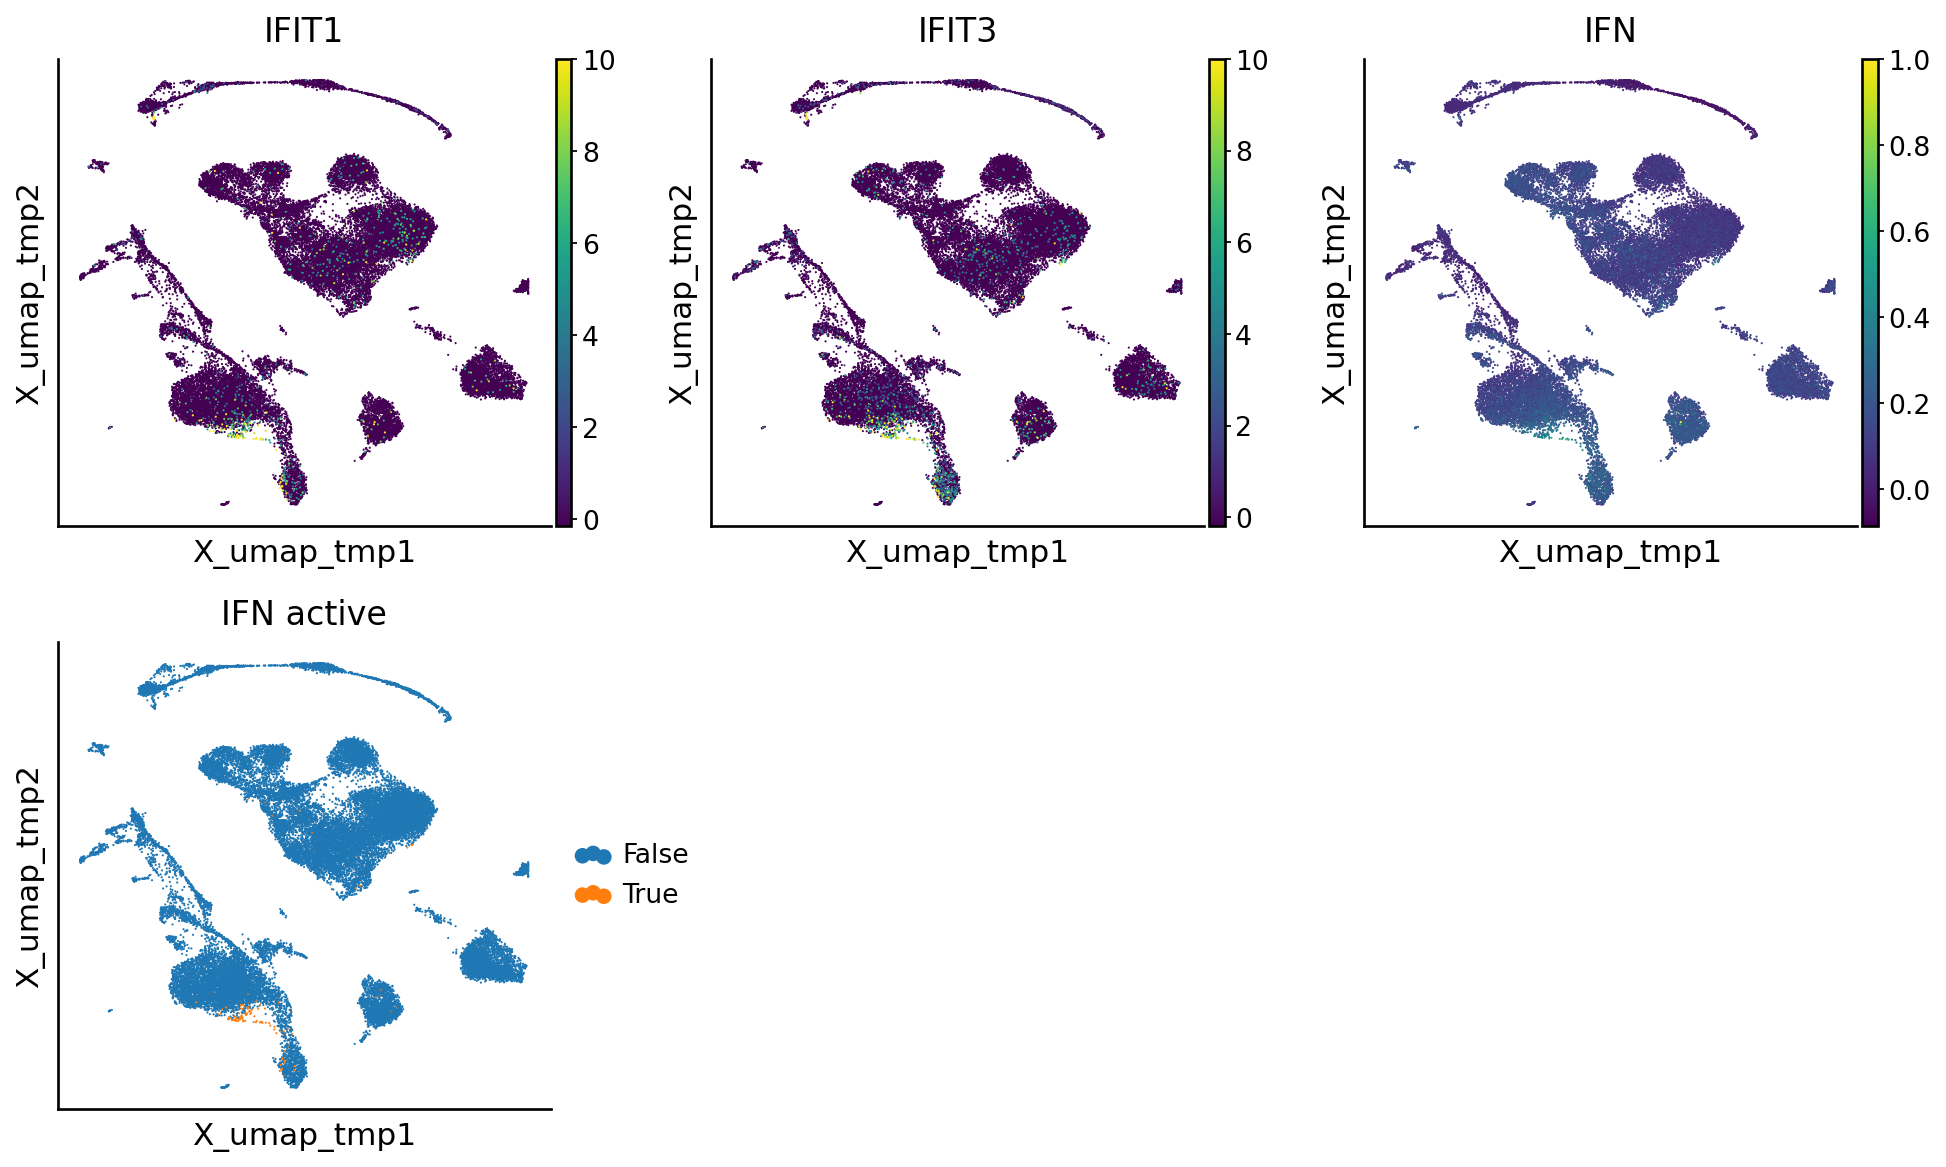

In [41]:
adata_full.obsm['X_umap_tmp'] = embeds['DRVI'][adata.obs.index].obsm['X_umap']
sc.pl.embedding(adata_full, "X_umap_tmp", color=['IFIT1', 'IFIT3', 'IFN', 'IFN active'], ncols=3)

In [42]:
# Create a mapping for sorting based on the prettified names
def get_order_index(raw_name):
    pretty = pretify_method_name(raw_name)
    try:
        return methods_general_order.index(pretty)
    except ValueError:
        return len(methods_general_order) # Push unknown methods to the end

sorted_embed_keys = sorted(embeds.keys(), key=get_order_index)
sorted_embeds = [(k, embeds[k]) for k in sorted_embed_keys]

most_relevant_dim_ifn = {}
smi_scoresifn = {}

for raw_method_name, embed in sorted_embeds:
    method_name = pretify_method_name(raw_method_name)
    print(method_name)
    
    # Store relevant IFN columns in the embedding object
    embed.obs['IFN'] = adata_full.obs['IFN']
    embed.obs['IFN active'] = adata_full.obs['IFN active']
    embed.obs['IFIT3'] = adata_full[embed.obs.index][:, ['IFIT3']].layers['lognorm'].toarray().flatten()
    embed.obs['IFIT2'] = adata_full[embed.obs.index][:, ['IFIT2']].layers['lognorm'].toarray().flatten()
    embed.obs['IFIT1'] = adata_full[embed.obs.index][:, ['IFIT1']].layers['lognorm'].toarray().flatten()
    embed.obs['ISG15'] = adata_full[embed.obs.index][:, ['ISG15']].layers['lognorm'].toarray().flatten()
    
    # Run Benchmark against IFN active
    bench = DiscreteDisentanglementBenchmark(
        embed.X, discrete_target=embed.obs['IFN active'], one_hot_target=None,
        dim_titles=embed.var['title']
    )
    bench.evaluate()
    scores = bench.get_results_details()['SMI'][True].sort_values(ascending=False)
    
    # Save results
    best_dim = scores.index[0]
    most_relevant_dim_ifn[raw_method_name] = best_dim
    # smi_scoresifn[raw_method_name] = scores[0]
    # Find continious score
    embed_df = embed.copy()
    embed_df.var.set_index('title', inplace=True)
    embed_df = embed_df.to_df()
    embed_df = pd.concat([embed_df, embed.obs], axis=1)
    smi_scoresifn[raw_method_name] = calc_normalized_mi(embed_df[best_dim], embed_df['IFN'])
    
    print(best_dim, scores[0])

DRVI
DR 2 0.5235817830860676
scETM
Dim 28 0.1446757028752924
LIGER
Dim 29 0.18973110231249846
MOFA
Dim 17 0.23979493832319815
ICA
Dim 9 0.5216656099598674
PCA
Dim 30 0.35700548625231815


In [43]:
adata_full.var.loc['ISG15']

hvg                       True
gene_de_sig    CD16+ Monocytes
mean                  0.258249
std                   0.444601
Name: ISG15, dtype: object

In [ ]:
plot_benchmark_scatter(
    sorted_embeds=sorted_embeds,
    most_relevant_dim=most_relevant_dim_ifn,
    smi_scores=smi_scoresifn,
    y_col='IFN',
    color_col='ISG15',
    sort_cols=[], 
    is_continuous=True,
    cmap='copper',
    y_label="IFN score",
    s=2,
    alpha=1.0
)
# Save as a single combined PDF
plt.savefig(output_dir / "combined_ifn_scatter.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
fig = plot_best_dims_interpretability(
        interpretability_dfs=int_dfs,
        most_relevant_dim=most_relevant_dim_ifn,
        n_top_genes=5,
        show=False,  # Changed to False so it returns the figure
        drvi_direction='+',
        model_directions={
            'ICA': '-',
            'PCA': '+',
            'MOFA': '+',
        }
    )

fig.savefig(output_dir / "interpretability_comparison_ifn.pdf", bbox_inches='tight', dpi=300)